In [1]:
# Libraries
import pandas as pd
import numpy as np

# CPU Cores & System
import os
import sys
import psutil

# Jalankan ini hanya jika posisi aktif masih di dalam folder notebooks
if os.getcwd().endswith('notebooks'):
    %cd ..

# Scipy
from scipy.stats import (
    chi2_contingency, 
    ks_2samp, spearmanr
)

# Viz libraries
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

# Plotting options
%matplotlib inline
mpl.style.use('ggplot')
sns.set(style='whitegrid')

# Import warnings
import warnings
warnings.filterwarnings('ignore')

# Pandas set_option
pd.set_option('display.max_columns', None)

/home/gontommuhammad/credit_risk_modeling


---
# **1.0. Data Gathering and Understanding**: <br>

## **1.1. Import Data while Handling Duplicate**:

In [2]:
from src.utils import importData

# Define data path
data_path = 'data/raw/loan_data_2007_2014.csv'

df = importData(data_path)

Origin Data Shape: (466285, 75) - (# Observation, # Column)

...handling duplicate data:
Sum of duplicate data: 0
Shape of duplicated rows: (0, 75)

Before drop rows: (466285, 75)
After drop rows: (466285, 75)


In [3]:
df.head()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-85,1.0,NaN,NaN,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,Jan-15,171.62,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-99,5.0,NaN,NaN,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,small_business,real estate business,606xx,IL,8.72,0.0,Nov-01,2.0,NaN,NaN,2.0,0.0,2956,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,Jun-14,649.91,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > to pay for prop...,other,personel,917xx,CA,20.00,0.0,Feb-96,1.0,35.0,NaN,10.0,0.0,5598,21.0,37.0,f,0.0,0.0,12226.302210,12226.30,10000.00,2209.33,16.97,0.00,0.00,Jan-15,357.48,NaN,Jan-15,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,B5,University Medical Group,1 year,RENT,80000.0,Source Verified,Dec-11,Current,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > I plan on combi...,other,Personal,972xx,OR,17.94,0.0,Jan-96,0.0,38.0,NaN,15.0,0.0,27783,53.9,38.0,f,766.9,766.9,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,Jan-16,67.79,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## **1.2. Data Dictionary of Loan Data - Credit Risk**:

| Feature Name                   | Description                            |
|--------------------------------|----------------------------------------|
| acc_now_delinq | The number of accounts on which the borrower is now delinquent. |
| addr_state | The state provided by the borrower in the loan application. |
| all_util | Balance to credit limit on all trades. |
| annual_inc | The self-reported annual income provided by the borrower during registration. |
| annual_inc_joint | The combined self-reported annual income provided by the co-borrowers during registration. | 
| application_type | Indicates whether the loan is an individual application or a joint application with two co-borrowers. |
| collection_recovery_fee | post charge off collection fee. |
| collections_12_mths_ex_med | Number of collections in 12 months excluding medical collections. |
| delinq_2yrs | The number of 30+ days past-due incidences of delinquency in the borrower(s) credit file for the past 2 years. |
| desc | Loan description provided by the borrower |
| dti | - |
| dti_joint | A ratio calculated using the co-borrowers total monthly payments on the total debt obligations, excluding mortgages and the requested LC loan, divided by the co-borrower(s) combined self-reported monthly income. |
| earliest_cr_line | The month the borrower(s) earliest reported credit line was opened. |
| emp_length | Employment length in years. Possible values are between 0 and 10 where 0 means less than one year and 10 means ten or more years. |
| emp_title | The job title supplied by the Borrower when applying for the loan. |
| funded_amnt | The total amount committed to that loan at that point in time. |
| funded_amnt_inv | - |
| grade | LC assigned loan grade. |
| home_ownership | The home ownership status provided by the borrower during registration. Our values are: RENT, OWN, MORTGAGE, OTHER. |
| id | A unique LC assigned ID for the loan listing. |
| il_util | Ratio of total current balance to high credit/credit limit on all install acct. |
| initial_list_status | The initial listing status of the loan. Possible values are – Whole, Fractional. |
| inq_fi | Number of personal finance inquiries. |
| inq_last_12m | Number of credit inquiries in past 12 months. |
| inq_last_6mths | The number of inquiries in past 6 months (excluding auto and mortgage inquiries). |
| installment  | The monthly payment owed by the borrower if the loan originates. |
| int_rate | Indicates if income was verified by LC, not verified, or if the income source was verified. |
| issue_d | The month which the loan was funded. |
| last_credit_pull_d | - |
| last_pymnt_amnt | Last total payment amount received. |
| last_pymnt_d | Last month payment was received. |
| loan_amnt |  |
| loan_status | Current status of the loan. |
| max_bal_bc | Maximum current balance owed on all revolving accounts. |
| member_id | A unique LC assigned Id for the borrower member. |
| mths_since_last_delinq | The number of months since the borrower's last delinquency. |
| mths_since_last_major_derog | Months since most recent 90-day or worse rating. |
| mths_since_last_record | The number of months since the last public record. |
| mths_since_rcnt_il | Months since most recent installment accounts opened. |
| next_pymnt_d | Next scheduled payment date. |
| open_acc | The number of open credit lines in the borrower's credit file. |
| open_acc_6m | Number of open trades in last 6 months. |
| open_il_12m | Number of installment accounts opened in past 12 months. |
| open_il_24m | Number of installment accounts opened in past 24 months. |
| open_il_6m | Number of installment accounts opened in past 6 months. |
| open_rv_12m | Number of revolving trades opened in past 12 months. |
| open_rv_24m | Number of revolving trades opened in past 24 months. |
| out_prncp | Remaining outstanding principal for total amount funded. |
| out_prncp_inv | Remaining outstanding principal for portion of total amount funded by investors. |
| policy_code | publicly available policy_code=1, new products not publicly available policy_code=2|
| pub_rec | Number of derogatory public records. |
| purpose | A category provided by the borrower for the loan request. |
| pymnt_plan | - |
| recoveries | Indicates if a payment plan has been put in place for the loan. |
| revol_bal | Total credit revolving balance. |
| revol_util | Revolving line utilization rate, or the amount of credit the borrower is using relative to all available revolving credit. |
| sub_grade | LC assigned loan subgrade. |
| term | The number of payments on the loan. Values are in months and can be either 36 or 60. |
| title | The loan title provided by the borrower. |
| tot_coll_amt | Total collection amounts ever owed. |
| tot_cur_bal | Total current balance of all accounts. |
| total_acc | The total number of credit lines currently in the borrower's credit file. |
| total_bal_il | Total current balance of all installment accounts. |
| total_cu_tl | Number of finance trades. |
| total_pymnt | Payments received to date for total amount funded. |
| total_pymnt_inv | Payments received to date for portion of total amount funded by investors. |
| total_rec_int | Interest received to date. |
| total_rec_late_fee | Late fees received to date. |
| total_rec_prncp | Principal received to date. |
| total_rev_hi_lim | Total revolving high credit/credit limit. |
| url | URL for the LC page with listing data. |
| verification_status | - |
| verification_status_joint | Indicates if the co-borrowers' joint income was verified by LC, not verified, or if the income source was verified.|
| zip_code | The first 3 numbers of the zip code provided by the borrower in the loan application. |

*Employer Title replaces Employer Name for all loans listed after 9/23/2013

<br>

Sort columns alphabetically:

In [4]:
df = df[sorted(df.columns)]

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   acc_now_delinq               466256 non-null  float64
 2   addr_state                   466285 non-null  str    
 3   all_util                     0 non-null       float64
 4   annual_inc                   466281 non-null  float64
 5   annual_inc_joint             0 non-null       float64
 6   application_type             466285 non-null  str    
 7   collection_recovery_fee      466285 non-null  float64
 8   collections_12_mths_ex_med   466140 non-null  float64
 9   delinq_2yrs                  466256 non-null  float64
 10  desc                         125981 non-null  str    
 11  dti                          466285 non-null  float64
 12  dti_joint                    0 non-null       float64
 13  earliest_c

In [5]:
df = df.set_index('member_id')

# Check if the index is unique
print(f"Is the index unique? {df.index.is_unique}")
print(f"Data shape: {df.shape}")

df_dupes = df[df.index.duplicated(keep=False)]
df_dupes

Is the index unique? True
Data shape: (466285, 74)


,Unnamed: 0,acc_now_delinq,addr_state,all_util,annual_inc,annual_inc_joint,application_type,collection_recovery_fee,collections_12_mths_ex_med,delinq_2yrs,desc,dti,dti_joint,earliest_cr_line,emp_length,emp_title,funded_amnt,funded_amnt_inv,grade,home_ownership,id,il_util,initial_list_status,inq_fi,inq_last_12m,inq_last_6mths,installment,int_rate,issue_d,last_credit_pull_d,last_pymnt_amnt,last_pymnt_d,loan_amnt,loan_status,max_bal_bc,mths_since_last_delinq,mths_since_last_major_derog,mths_since_last_record,mths_since_rcnt_il,next_pymnt_d,open_acc,open_acc_6m,open_il_12m,open_il_24m,open_il_6m,open_rv_12m,open_rv_24m,out_prncp,out_prncp_inv,policy_code,pub_rec,purpose,pymnt_plan,recoveries,revol_bal,revol_util,sub_grade,term,title,tot_coll_amt,tot_cur_bal,total_acc,total_bal_il,total_cu_tl,total_pymnt,total_pymnt_inv,total_rec_int,total_rec_late_fee,total_rec_prncp,total_rev_hi_lim,url,verification_status,verification_status_joint,zip_code
member_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,


---
## **1.3. Handling Target Features**: <br>

`loan_status` is the target feature:

In [6]:
df['loan_status'].unique()

<StringArray>
[                                         'Fully Paid',
                                         'Charged Off',
                                             'Current',
                                             'Default',
                                  'Late (31-120 days)',
                                     'In Grace Period',
                                   'Late (16-30 days)',
  'Does not meet the credit policy. Status:Fully Paid',
 'Does not meet the credit policy. Status:Charged Off']
Length: 9, dtype: str

In [7]:
df['loan_status'].value_counts()

loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64

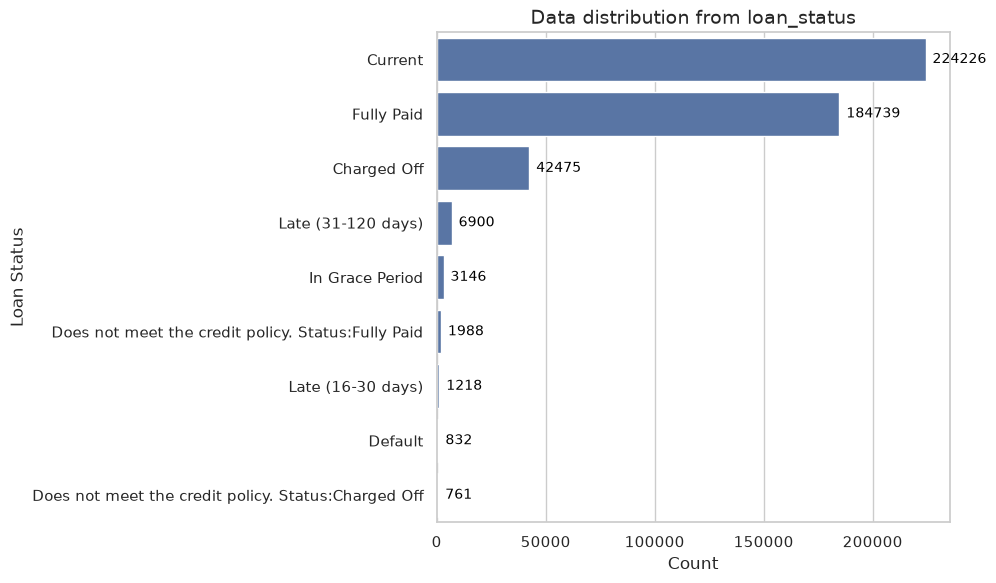

In [8]:
# Visualization of `loan_status` distribution
plt.figure(figsize=(10, 6))

ax = sns.countplot(y='loan_status', data=df, order=df['loan_status'].value_counts().index)

plt.title(f'Data distribution from loan_status', fontsize=14)
plt.xlabel(f'Count')
plt.ylabel(f'Loan Status')

for p in ax.patches:
    count = int(p.get_width())
    ax.annotate(f'{count}', 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', fontsize=10, color='black', xytext=(5, 0),
                textcoords='offset points')

plt.tight_layout()
plt.show()

<br>

**Current** status:

In [9]:
# Create an object for Current
current = ['Current']

# Count the number of rows with loan_status in Current
count_current = df[df['loan_status'].isin(current)].shape[0]

# Total number of rows
total_rows = len(df)

# Calculate percentage
percentage_current = (count_current / total_rows) * 100

# Get rows that have loan_status in Current
df_current = df[df['loan_status'].isin(current)]

# Print and check the dataframe
print(f"Number of rows with `Current` status: {count_current} of {total_rows}")
print(f"Percentage of `Curremt` status of total data: {percentage_current:.6f}%")
print(f"Expected rows after drop: {total_rows - count_current}")

Number of rows with `Current` status: 224226 of 466285
Percentage of `Curremt` status of total data: 48.087757%
Expected rows after drop: 242059


- We decided to remove **Current** status cause we can't decide this with bad or good;
- and transform the target feature to binary:

In [10]:
# Delete lines that fall within the Current status
df = df[~df['loan_status'].isin(current)]

# Define a list for statuses that are considered "Good"
good_statuses = [
    'Fully Paid',  
    'Does not meet the credit policy. Status:Fully Paid'
]

# Create a new column 'target' with the condition: If it is in the good_statuses list then 0, otherwise bad: 1
df['y'] = np.where(df['loan_status'].isin(good_statuses), 0, 1)

# Drop the loan_status column
df = df.drop(columns=['loan_status'])

# Sanity check: make sure the column no longer exists
print(f"is the 'loan_status' feature still available? {'loan_status' in df.columns}")  # False means it has been deleted
print(f"Is it true that the row shape is as expected: {df.shape[0] == total_rows - count_current}; The Data shape is: {df.shape}")

is the 'loan_status' feature still available? False
Is it true that the row shape is as expected: True; The Data shape is: (242059, 74)


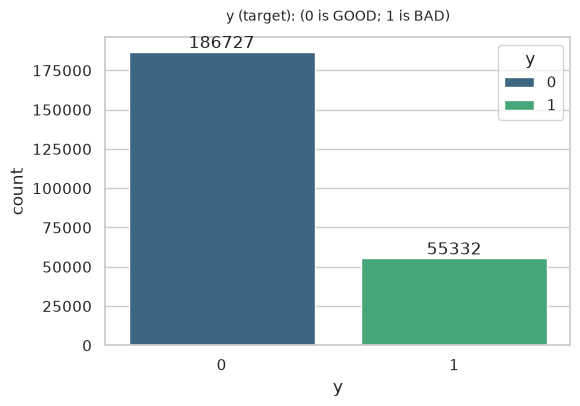

In [11]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(6,4))

# Plot countplot
sns.countplot(data=df, x='y', hue='y', palette='viridis', ax=ax)

# Add bar label
for container in ax.containers: 
    ax.bar_label(container, fmt='%d')

# Title
ax.set_title('y (target): (0 is GOOD; 1 is BAD)', fontsize=10, pad=12)

# Save figure before show
fig.savefig('Target_Feature_Distribution.png', dpi=150, bbox_inches='tight')

# Show
plt.show()

In [12]:
df['y'].value_counts()

y
0    186727
1     55332
Name: count, dtype: int64

<br>

---
# **2.0. Exploratory Data Analysis: Data Wrangling & Cleaning**:

<br>

**Missing Value Check**:

In [13]:
from src.utils import missing_summary
missing_summary(df)

,Missing Values,Percentage,Total length
acc_now_delinq,29,0.01,242059
all_util,242059,100.00,242059
annual_inc,4,0.00,242059
annual_inc_joint,242059,100.00,242059
collections_12_mths_ex_med,145,0.06,242059
delinq_2yrs,29,0.01,242059
desc,149405,61.72,242059
dti_joint,242059,100.00,242059
earliest_cr_line,29,0.01,242059
emp_length,9327,3.85,242059


<br>

**Drop `NaN` values that add up to 100% and unnecessary features**:

In [14]:
# list of features that have 100% NaN value
null_100 = df.columns[df.isnull().mean() == 1.0]
print(f"Columns with 100% null values: {null_100}")

# Perform feature removal
df = df.drop(columns=null_100)

print(f"\nAre there still any columns with 100% NaN? {(df.isnull().mean() == 1.0).any()}")

Columns with 100% null values: Index(['all_util', 'annual_inc_joint', 'dti_joint', 'il_util', 'inq_fi',
       'inq_last_12m', 'max_bal_bc', 'mths_since_rcnt_il', 'open_acc_6m',
       'open_il_12m', 'open_il_24m', 'open_il_6m', 'open_rv_12m',
       'open_rv_24m', 'total_bal_il', 'total_cu_tl',
       'verification_status_joint'],
      dtype='str')

Are there still any columns with 100% NaN? False


In [15]:
# List of unimportant features for modeling
unimportant_features = [
    'Unnamed: 0', 'addr_state', 'desc', 'emp_title', 'id', 'url', 'zip_code', 'next_pymnt_d',
]

# Perform feature removal
df = df.drop(columns=unimportant_features)

print(f"Still there? {[col for col in unimportant_features if col in df.columns]}")

Still there? []


<br>

Handles features that should be of type datetime:

In [16]:
df[['issue_d', 'last_pymnt_d', 'earliest_cr_line', 'last_credit_pull_d']]

,issue_d,last_pymnt_d,earliest_cr_line,last_credit_pull_d
member_id,,,,
1296599,Dec-11,Jan-15,Jan-85,Jan-16
1314167,Dec-11,Apr-13,Apr-99,Sep-13
1313524,Dec-11,Jun-14,Nov-01,Jan-16
1277178,Dec-11,Jan-15,Feb-96,Jan-15
1311441,Dec-11,Jan-15,Nov-04,Sep-15
...,...,...,...,...
11547808,Jan-14,May-14,Nov-94,Oct-14
10799568,Jan-14,Nov-14,Jul-98,Oct-14
11597671,Jan-14,Sep-15,Jun-02,Jan-16


In [17]:
missing_summary(df[['issue_d', 'last_pymnt_d', 'earliest_cr_line', 'last_credit_pull_d']])

,Missing Values,Percentage,Total length
last_pymnt_d,376,0.16,242059
earliest_cr_line,29,0.01,242059
last_credit_pull_d,23,0.01,242059


In [18]:
# Define the date columns
date_columns = ['issue_d', 'last_pymnt_d', 'earliest_cr_line', 'last_credit_pull_d']

# Count the number of rows that have NaN in any of those columns
expected_drop = df[date_columns].isnull().any(axis=1).sum()
print(f"Expected rows to drop:", expected_drop)

# Validate with total rows before drop
print(f"Total rows before drop:", df.shape[0])

# Drop NaN
df = df.dropna(subset=date_columns)

# Validation after drop
print(f"Total rows after drop:", df.shape[0])

Expected rows to drop: 427
Total rows before drop: 242059
Total rows after drop: 241632


In [19]:
# Convert to datetime & fix "future" year simultaneously (Vectorization)
for col in date_columns:
    # Biarkan Pandas menebak format %b-%y (e.g., Jan-14, Dec-68)
    df[col] = pd.to_datetime(df[col], format='%b-%y', errors='coerce')
    
    # Correction if the year jumps into the future (beyond the anchor year 2016)
    # Pandas automatically detects the year '68' as '2068', we change it to '1968'
    future_mask = df[col].dt.year > 2016
    df.loc[future_mask, col] = df.loc[future_mask, col] - pd.DateOffset(years=100)

# Calculates `payment_time` in months
# 'last_pymnt_d': Last month payment was received.
# 'issue_d': The month which the loan was funded.
df['pymnt_time_month'] = (
    (df['last_pymnt_d'].dt.year - df['issue_d'].dt.year) * 12 + \
    (df['last_pymnt_d'].dt.month - df['issue_d'].dt.month)
).fillna(0).astype(int)

# Calculates `credit_history_age_` in months
# 'earliest_cr_line': The first month the user has a credit history.
# 'issue_d': The month the loan was approved/issued.
df['credit_history_age_month'] = (
    (df['issue_d'].dt.year - df['earliest_cr_line'].dt.year) * 12 + \
    (df['issue_d'].dt.month - df['earliest_cr_line'].dt.month)
).fillna(0).astype(int)


# # In production, 'issue_d' is replaced with today's date when the user clicks "Apply"
# todays_date = pd.Timestamp.now()

# credit_history_age_month = (
#     (todays_date.year - earliest_cr_line.year) * 12 + \
#     (todays_date.month - earliest_cr_line.month)
# )

# Display the final resulting DataFrame
df[['issue_d', 'last_pymnt_d', 'earliest_cr_line', 'last_credit_pull_d', 'pymnt_time_month', 'credit_history_age_month', 'y']]

,issue_d,last_pymnt_d,earliest_cr_line,last_credit_pull_d,pymnt_time_month,credit_history_age_month,y
member_id,,,,,,,
1296599,2011-12-01,2015-01-01,1985-01-01,2016-01-01,37,323,0
1314167,2011-12-01,2013-04-01,1999-04-01,2013-09-01,16,152,1
1313524,2011-12-01,2014-06-01,2001-11-01,2016-01-01,30,121,0
1277178,2011-12-01,2015-01-01,1996-02-01,2015-01-01,37,190,0
1311441,2011-12-01,2015-01-01,2004-11-01,2015-09-01,37,85,0
...,...,...,...,...,...,...,...
11547808,2014-01-01,2014-05-01,1994-11-01,2014-10-01,4,230,1
10799568,2014-01-01,2014-11-01,1998-07-01,2014-10-01,10,186,1
11597671,2014-01-01,2015-09-01,2002-06-01,2016-01-01,20,139,0


In [20]:
# misalnya untuk kolom date_columns
for col in date_columns:
    print(f"Column: {col}")
    print(f"Min :", df[col].min())
    print(f"Max :", df[col].max())
    print(f"Count :", df[col].notna().sum())
    print()

Column: issue_d
Min : 2007-06-01 00:00:00
Max : 2014-12-01 00:00:00
Count : 241632

Column: last_pymnt_d
Min : 2007-12-01 00:00:00
Max : 2016-01-01 00:00:00
Count : 241632

Column: earliest_cr_line
Min : 1946-01-01 00:00:00
Max : 2011-11-01 00:00:00
Count : 241632

Column: last_credit_pull_d
Min : 2007-05-01 00:00:00
Max : 2016-01-01 00:00:00
Count : 241632



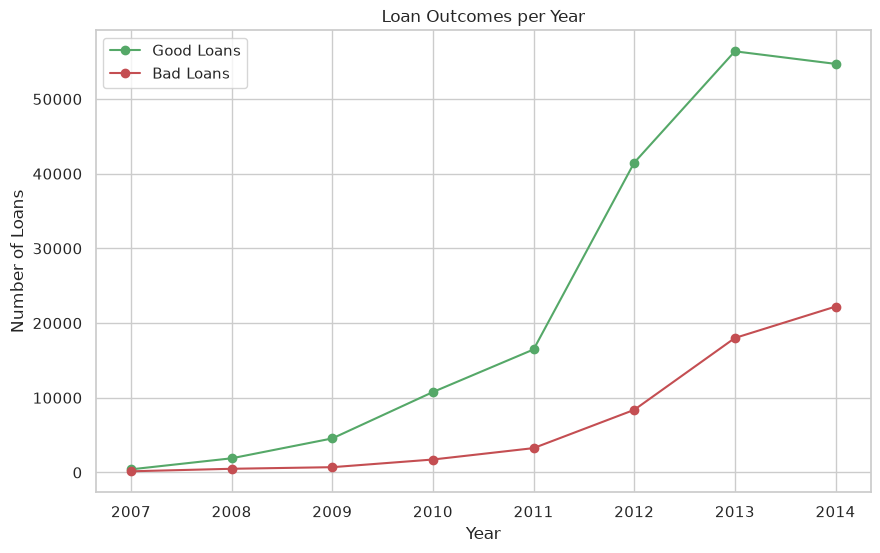

In [21]:
good_loan = df[df['y'] == 0]
bad_loan  = df[df['y'] == 1]

good_loan['year'] = good_loan['issue_d'].dt.year
bad_loan['year']  = bad_loan['issue_d'].dt.year

achievements_per_year = good_loan.groupby('year').size()
failures_per_year = bad_loan.groupby('year').size()

# Visualisasi
plt.figure(figsize=(10,6))
plt.plot(achievements_per_year.index, achievements_per_year.values, 
         marker='o', color='g', label='Good Loans')
plt.plot(failures_per_year.index, failures_per_year.values, 
         marker='o', color='r', label='Bad Loans')

plt.title(f'Loan Outcomes per Year')
plt.xlabel(f'Year')
plt.ylabel(f'Number of Loans')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# df.drop(columns=['issue_d', 'last_pymnt_d', 'earliest_cr_line',], inplace=True)

In [ ]:
# List of columns to be visualized
cols = ['credit_history_age_month', 'pymnt_time_month']

from src.utils import plot_numeric_distributions

plot_numeric_distributions(dataframe=df[cols], target_col=df['y'])

In [ ]:
# Create credit age categories (in years)
df['credit_age_years'] = df['credit_history_age_month'] / 12

def group_age(years):
    if years < 5: return 'less_5'
    elif years <= 15: return '5_15'
    else: return 'greater_15'

df['credit_age_group'] = df['credit_age_years'].apply(group_age)

# Check the default ratio (y=1) in each group
df.groupby('credit_age_group')['y'].mean().sort_values(ascending=False)

In [ ]:
df[['credit_age_group', 'credit_age_years', 'credit_history_age_month']]

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Menggunakan Random Forest sederhana untuk cek Feature Importance
X_ = df[[
    'credit_history_age_month', 'annual_inc', 'dti', 'inq_last_6mths', 'loan_amnt', 'open_acc', 'pub_rec',
    'revol_bal', 'revol_util', 'delinq_2yrs', 'total_rev_hi_lim', 'tot_cur_bal', 'tot_coll_amt', 'total_acc',
]]

y_ = df['y']

rf = RandomForestClassifier(max_depth=5, random_state=42)
rf.fit(X_, y_)
print(f"Feature Importance: {rf.feature_importances_[0]:.6f}")

In [ ]:
# Ambil semua feature importance
importances = rf.feature_importances_

# Gabungkan dengan nama kolom X_
feat_importance_df = pd.DataFrame({
    'Feature': X_.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feat_importance_df

<br>

**WoE (Weight of Evidence) Implementation for Feature Selection**:

In [ ]:
# 1. Perform Automatic Binning (e.g. divide into 6 groups based on quantiles to balance the amount of data)
# We can also use manual bins if we want to customize
df['credit_age_bin'] = pd.qcut(df['credit_history_age_month'], q=6, duplicates='drop').astype(str)

# 2. Calculate the total of Good (y=0) and Bad (y=1) across the entire dataset
total_good = (df['y'] == 0).sum()
total_bad = (df['y'] == 1).sum()

# 3. Count the number of Good and Bad in each Bin
woe_df = df.groupby('credit_age_bin')['y'].agg(
    total_records='count',
    bad_counts='sum'
).reset_index()

df_good_counts = df[df['y'] == 0].groupby('credit_age_bin').size().reset_index(name='good_counts')
woe_df = pd.merge(woe_df, df_good_counts, on='credit_age_bin', how='left').fillna(0)

# 4. Calculate the % Good and % Bad Distribution
woe_df['dist_good'] = woe_df['good_counts'] / total_good
woe_df['dist_bad'] = woe_df['bad_counts'] / total_bad

# 5. Calculate WoE Value (add a very small value of 0.0001 to avoid dividing by zero/log zero)
woe_df['WoE'] = np.log((woe_df['dist_good'] + 1e-4) / (woe_df['dist_bad'] + 1e-4))

# 6. Calculate the Information Value (IV) at the same time to check the mathematical strength of the feature.
woe_df['IV_components'] = (woe_df['dist_good'] - woe_df['dist_bad']) * woe_df['WoE']
total_iv = woe_df['IV_components'].sum()

print(f"Total Information Value (IV) untuk fitur ini: {total_iv:.4f}")
print(f"\nWoE Reference Table per Groupk:")
print(woe_df[['credit_age_bin', 'good_counts', 'bad_counts', 'WoE']])

# 7. Mapping WoE values back to the main DataFrame for use by Logistic Regression (if results are good)
woe_map = dict(zip(woe_df['credit_age_bin'], woe_df['WoE']))
df['credit_history_age_woe'] = df['credit_age_bin'].map(woe_map)

In [ ]:
df['credit_age_group'].value_counts()

In [ ]:
df.groupby('credit_age_group')['y'].mean().sort_values(ascending=False)

In [ ]:
ct_count_age_group = pd.crosstab(df['credit_age_group'], df['y'])
ct_percent_age_group = pd.crosstab(df['credit_age_group'], df['y'], normalize='index') * 100

print(f"Count: \n{ct_count_age_group}")
print(f"\nPercentage: \n{ct_percent_age_group.round(2)}")

# Chi-Square & p-value
chi2, p, dof, expected = chi2_contingency(ct_count_age_group)
print(f"\nChi-square statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degree of Freedom: {dof}")

In [ ]:
sns.barplot(
    x='y', 
    y='credit_age_group', 
    data=df, 
    estimator=lambda x: sum(x)/len(x)  # average default rate per category
)
plt.title(f"Default Rate (y=1) per Credit Age Group")
plt.show()

In [ ]:
df.drop(
    columns=[
        'credit_history_age_woe', 'credit_age_bin', 'credit_age_years', 
        'pymnt_time_month', 'credit_history_age_month'], inplace=True
)
set(['credit_history_age_woe', 'credit_age_bin', 'credit_age_years', 'pymnt_time_month', 'credit_history_age_month']).intersection(df.columns)

In [ ]:
df['credit_age_group'] = df['credit_age_group'].astype('category')

<br>

---
### `application_type`: 
Indicates whether the loan is an individual application or a joint application with two co-borrowers.

In [ ]:
df['application_type'].value_counts(normalize=True)

In [ ]:
df.drop(columns=['application_type'], inplace=True)

<br>

---
### `purpose` and `title`:

In [ ]:
df[['purpose', 'title']].sample(5)

In [ ]:
df['purpose'].describe()

In [ ]:
df['purpose'].unique()

In [ ]:
df['purpose'].value_counts()

In [ ]:
ct_count_purpose = pd.crosstab(df['purpose'], df['y'])
ct_percent_purpose = pd.crosstab(df['purpose'], df['y'], normalize='index') * 100

print(f"Count: \n{ct_count_purpose}")
print(f"\nPercentage: \n{ct_percent_purpose.round(2)}")

# Chi-Square & p-value
chi2, p, dof, expected = chi2_contingency(ct_count_purpose)
print(f"\nChi-square statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degree of Freedom: {dof}")

In [ ]:
# Validate the number of values on the feature before and after
before_other = df['purpose'].value_counts()['other']
added = df['purpose'].value_counts()['renewable_energy'] + df['purpose'].value_counts()['moving'] + \
        df['purpose'].value_counts()['vacation']

# Mapping category to 'other'
df['purpose'] = df['purpose'].replace({
    'renewable_energy': 'other',
    'moving': 'other',
    'vacation': 'other'
})

# validasi jumlah sebelum dan sesudah
after_other = df['purpose'].value_counts()['other']

print(f"Number of 'other' before:", before_other)
print(f"Additional amount (renewable_energy + moving + vacation):", added)
print(f"Number of 'other' after:", after_other)
print(f"Validation:", before_other + added == after_other)

In [ ]:
df['purpose'] = df['purpose'].astype('category')

In [ ]:
df['purpose'].unique()

In [ ]:
df['purpose'].value_counts()

In [ ]:
ct_count_purpose = pd.crosstab(df['purpose'], df['y'])
ct_percent_purpose = pd.crosstab(df['purpose'], df['y'], normalize='index') * 100

print(f"Count: \n{ct_count_purpose}")
print(f"\nPercentage: \n{ct_percent_purpose.round(2)}")

# Chi-Square & p-value
chi2, p, dof, expected = chi2_contingency(ct_count_purpose)
print(f"\nChi-square statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degree of Freedom: {dof}")

# Calculate default rate per title category
default_rate_df = (
    df.groupby('purpose')['y']
      .mean()
      .reset_index()
      .sort_values('y', ascending=False)
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=default_rate_df,
    x='y', 
    y='purpose',
    order=default_rate_df['purpose'],   # urutkan sesuai hasil sort
    color='skyblue'
)
plt.ylabel(f"Purpose")
plt.xlabel(f"Default Rate (%) Bad Loan (y=1)")
plt.title(f"Default Rate per Purpose")
plt.show()

ct_long = ct_count_purpose.reset_index().melt(
    id_vars='purpose', 
    value_vars=[0,1], 
    var_name='Loan_Status', 
    value_name='Count'
)
plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=ct_long,
    x='purpose', y='Count', hue='Loan_Status',
    palette=['green','red']
)
plt.title(f"Distribution of Good vs Bad Loans per Purpose")
plt.xlabel(f"Purpose")
plt.ylabel(f"Count")
plt.xticks(rotation=25, ha='right')

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ["Good Loan (y=0)", "Bad Loan (y=1)"], title="Loan_Status")

plt.tight_layout()
plt.show()

In [ ]:
df['title'].describe()

* We will drop the `title` feature because it is too complex for modeling.

In [ ]:
df.drop(columns=['title'], inplace=True)

<br>

---
### `sub_grade` and `grade`:

In [ ]:
df[['grade', 'sub_grade']].sample(5)

In [ ]:
df['grade'].describe()

In [ ]:
df['grade'].value_counts()

In [ ]:
df['sub_grade'].describe()

In [ ]:
df['sub_grade'].value_counts()

In [ ]:
ct_count_grade = pd.crosstab(df['grade'], df['y'])
ct_percent_grade = pd.crosstab(df['grade'], df['y'], normalize='index') * 100

print(f"Count: \n{ct_count_grade}")
print(f"\nPercentage: \n{ct_percent_grade.round(2)}")

# Chi-Square & p-value
chi2, p, dof, expected = chi2_contingency(ct_count_grade)
print(f"\nChi-square statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degree of Freedom: {dof}")

# Calculate default rate per title category
default_rate_df = (
    df.groupby('grade')['y']
      .mean()
      .reset_index()
      .sort_values('y', ascending=False)
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=default_rate_df,
    x='y', 
    y='grade',
    order=default_rate_df['grade'],
    color='skyblue'
)
plt.ylabel(f"Grade")
plt.xlabel(f"Default Rate (%) Bad Loan (y=1)")
plt.title(f"Default Rate per Grade")
plt.show()

ct_long = ct_count_grade.reset_index().melt(
    id_vars='grade', 
    value_vars=[0,1], 
    var_name='Loan_Status', 
    value_name='Count'
)
plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=ct_long,
    x='grade', y='Count', hue='Loan_Status',
    palette=['green','red']
)
plt.title(f"Distribution of Good vs Bad Loans per Grade")
plt.xlabel(f"Grade")
plt.ylabel(f"Count")
plt.xticks(rotation=30, ha='right')

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ["Good Loan (y=0)", "Bad Loan (y=1)"], title="Loan_Status")

plt.tight_layout()
plt.show()

In [ ]:
df['grade'] = df['grade'].astype('category')

In [ ]:
df['sub_grade'].value_counts()

In [ ]:
ct_count_subgrade = pd.crosstab(df['sub_grade'], df['y'])
ct_percent_subgrade = pd.crosstab(df['sub_grade'], df['y'], normalize='index') * 100

print(f"Count: \n{ct_count_subgrade}")
print(f"\nPercentage: \n{ct_percent_subgrade.round(2)}")

# Chi-Square & p-value
chi2, p, dof, expected = chi2_contingency(ct_count_subgrade)
print(f"\nChi-square statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degree of Freedom: {dof}")

# Calculate default rate per title category
default_rate_df = (
    df.groupby('sub_grade')['y']
      .mean()
      .reset_index()
      .sort_values('y', ascending=False)
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=default_rate_df,
    x='y', 
    y='sub_grade',
    order=default_rate_df['sub_grade'],
    color='skyblue'
)
plt.ylabel(f"Sub Grade")
plt.xlabel(f"Default Rate (%) Bad Loan (y=1)")
plt.title(f"Default Rate per Sub Grade")
plt.show()

ct_long = ct_count_subgrade.reset_index().melt(
    id_vars='sub_grade', 
    value_vars=[0,1], 
    var_name='Loan_Status', 
    value_name='Count'
)
plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=ct_long,
    x='sub_grade', y='Count', hue='Loan_Status',
    palette=['green','red']
)
plt.title(f"Distribution of Good vs Bad Loans per Sub Grade")
plt.xlabel(f"Sub Grade")
plt.ylabel(f"Count")
plt.xticks(rotation=30, ha='right')

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ["Good Loan (y=0)", "Bad Loan (y=1)"], title="Loan_Status")

plt.tight_layout()
plt.show()

In [ ]:
df['sub_grade'] = df['sub_grade'].astype('category')

<br>

---
### `policy_code`:

In [ ]:
df['policy_code'].value_counts(normalize=True) * 100

<br>

We drop **policy_code** (Zero Variance). <br> Unless something turns out otherwise in the future.

In [ ]:
df.drop(columns=['policy_code'], inplace=True)

<br>

---
### `emp_length`:
Employment Length.

In [ ]:
df['emp_length'].describe()

In [ ]:
df['emp_length'].value_counts()

In [ ]:
ct_count_length = pd.crosstab(df['emp_length'], df['y'])
ct_percent_length = pd.crosstab(df['emp_length'], df['y'], normalize='index') * 100

print(f"Count: \n{ct_count_length}")
print(f"\nPercentage: \n{ct_percent_length.round(2)}")

# Chi-Square & p-value
chi2, p, dof, expected = chi2_contingency(ct_count_length)
print(f"\nChi-square statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degree of Freedom: {dof}")

# Calculate default rate per title category
default_rate_df = (
    df.groupby('emp_length')['y']
      .mean()
      .reset_index()
      .sort_values('y', ascending=False)
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=default_rate_df,
    x='y', 
    y='emp_length',
    order=default_rate_df['emp_length'],
    color='skyblue'
)
plt.ylabel(f"emp_length")
plt.xlabel(f"Default Rate (%) Bad Loan (y=1)")
plt.title(f"Default Rate per emp_length")
plt.show()

ct_long = ct_count_length.reset_index().melt(
    id_vars='emp_length', 
    value_vars=[0,1], 
    var_name='Loan_Status', 
    value_name='Count'
)
plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=ct_long,
    x='emp_length', y='Count', hue='Loan_Status',
    palette=['green','red']
)
plt.title(f"Distribution of Good vs Bad Loans per emp_length")
plt.xlabel(f"emp_length")
plt.ylabel(f"Count")
plt.xticks(rotation=30, ha='right')

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ["Good Loan (y=0)", "Bad Loan (y=1)"], title="Loan_Status")

plt.tight_layout()
plt.show()

In [ ]:
df['emp_length'].unique()

In [ ]:
df['emp_length'].isna().sum()

In [ ]:
def process_emp_length(dataframe, col_name='emp_length'):
    import re
    """
    Fungsi untuk membersihkan teks, melakukan binning,
    dan membuat kategori baru untuk `np.nan`
    """
    df_processed = dataframe.copy()
    # ==========================================
    # 1. NUMBER EXTRACTION (Cleaning)
    # ==========================================
    # Change text like "< 1 year" to 0, "10+ years" to 10
    def extract_years(text):
        if pd.isna(text):
            return np.nan
        text = str(text)
        if '< 1' in text:
            return 0
        
        # Find all numbers in text
        nums = re.findall(r'\d+', text)
        return int(nums[0]) if nums else np.nan

    df_processed['emp_length_ordinal'] = df_processed[col_name].apply(extract_years)
    
    # ==========================================
    # 2. GROUP BINNING (pd.cut)
    # ==========================================
    # Define interval boundaries (bins) and group names (labels)
    # pd.cut rule: (lower_bound, upper_bound] -> exclusive lower bound, inclusive upper bound
    bins = [-1, 2, 5, 9, 100]  
    labels = ['New_Employee', 'Mid_Employee', 'Senior_Employee', 'Expert_Employee']
    
    # Mapping interval:
    # (-1, 2]   => 0, 1, 2 years (New)
    # (2, 5]    => 3, 4, 5 years (Mid)
    # (5, 9]    => 6, 7, 8, 9 years (Senior)
    # (9, 100]  => 10+ years (Expert)
    
    df_processed['emp_length_group'] = pd.cut(
        df_processed['emp_length_ordinal'], 
        bins=bins, 
        labels=labels
    )
    
    # We will create an 'No_Formal_Employee' category for `np.nan`
    df_processed['emp_length_group'] = df_processed['emp_length_group'].cat.add_categories(
        'No_Formal_Employee').fillna('No_Formal_Employee')

    return df_processed

df = process_emp_length(dataframe=df, col_name='emp_length')

In [ ]:
df[['emp_length', 'emp_length_ordinal', 'emp_length_group']].sample(12)

In [ ]:
df['emp_length_group'].unique()

In [ ]:
df['emp_length_ordinal'].unique()

In [ ]:
df.drop(columns=['emp_length', 'emp_length_ordinal'], inplace=True)

In [ ]:
ct_count_empgroup = pd.crosstab(df['emp_length_group'], df['y'])
ct_percent_empgroup = pd.crosstab(df['emp_length_group'], df['y'], normalize='index') * 100

print(f"Count: \n{ct_count_empgroup}")
print(f"\nPercentage: \n{ct_percent_empgroup.round(2)}")

# Chi-Square & p-value
chi2, p, dof, expected = chi2_contingency(ct_count_empgroup)
print(f"\nChi-square statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degree of Freedom: {dof}")

# Calculate default rate per title category
# Calculate default rate per title category
default_rate_df = (
    df.groupby('emp_length_group')['y']
      .mean()
      .reset_index()
      .sort_values('y', ascending=False)
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=default_rate_df,
    x='y', 
    y='emp_length_group',
    order=default_rate_df['emp_length_group'],   # urutkan sesuai hasil sort
    color='skyblue'
)

plt.ylabel(f"Group of Employee")
plt.xlabel(f"Default Rate (%) Bad Loan (y=1)")
plt.title(f"Default Rate per Group of Employee")
plt.show()

plt.figure(figsize=(10,6))
ct_count_empgroup.plot(kind='bar', stacked=False, color=['green','red'], figsize=(10,6))

plt.title(f"Distribution of Good vs Bad Loans per Group of Employee")
plt.xlabel(f"Group of Employee")
plt.ylabel(f"Count")
plt.legend(["Good Loan (y=0)", "Bad Loan (y=1)"])
plt.xticks(rotation=0)
plt.show()

In [ ]:
missing_summary(df.select_dtypes(include=[np.number, 'int64', 'float64']))

In [ ]:
missing_summary(df.select_dtypes(include=['object', 'str', 'category']))

In [ ]:
df.info()

---
### `collections_12_mths_ex_med`: 
Number of collections in 12 months excluding medical collections.

In [ ]:
df['collections_12_mths_ex_med'].describe()

In [ ]:
df['collections_12_mths_ex_med'].value_counts()

In [ ]:
df['collections_12_mths_ex_med'].unique()

In [ ]:
ct_count_col12 = pd.crosstab(df['collections_12_mths_ex_med'], df['y'])
ct_percent_col12 = pd.crosstab(df['collections_12_mths_ex_med'], df['y'], normalize='index') * 100

print(f"Count: \n{ct_count_col12}")
print(f"\nPercentage: \n{ct_percent_col12.round(2)}")

# Chi-Square & p-value
chi2, p, dof, expected = chi2_contingency(ct_count_col12)
print(f"\nChi-square statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degree of Freedom: {dof}")

# Calculate default rate per title category
default_rate_df = (
    df.groupby('collections_12_mths_ex_med')['y']
      .mean()
      .reset_index()
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=default_rate_df,
    x='y', 
    y='collections_12_mths_ex_med',
    order=default_rate_df['collections_12_mths_ex_med'],
    color='skyblue'
)
plt.ylabel(f"collections_12_mths_ex_med")
plt.xlabel(f"Default Rate (%) Bad Loan (y=1)")
plt.title(f"Default Rate per collections_12_mths_ex_med")
plt.show()

ct_long = ct_count_col12.reset_index().melt(
    id_vars='collections_12_mths_ex_med', 
    value_vars=[0,1], 
    var_name='Loan_Status', 
    value_name='Count'
)
plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=ct_long,
    x='collections_12_mths_ex_med', y='Count', hue='Loan_Status',
    palette=['green','red']
)
plt.title(f"Distribution of Good vs Bad Loans per collections_12_mths_ex_med")
plt.xlabel(f"collections_12_mths_ex_med")
plt.ylabel(f"Count")
plt.xticks(rotation=0, ha='right')

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ["Good Loan (y=0)", "Bad Loan (y=1)"], title="Loan_Status")

plt.tight_layout()
plt.show()

In [ ]:
def binarize_collections(dataframe, col_name='collections_12_mths_ex_med'):
    df_processed = dataframe.copy()
    
    # Create a simple mapping function
    def group_collections(val):
        if pd.isna(val):
            return 'Unknown' # Watch for `NaN` values
        elif val == 0:
            return 'No_Collections'
        else:
            return 'Has_Collections'
            
    # Apply to new column
    df_processed['collections_12mths_group'] = df_processed[col_name].apply(group_collections)

    # Change the data type to category
    df_processed['collections_12mths_group'] = df_processed['collections_12mths_group'].astype('category')
    
    # Delete the original numeric column to avoid duplication
    df_processed = df_processed.drop(columns=[col_name])
    
    return df_processed


df = binarize_collections(dataframe=df, col_name='collections_12_mths_ex_med')

# Check results
df[['collections_12mths_group']].describe()

In [ ]:
df['collections_12mths_group'].unique()

In [ ]:
df['collections_12mths_group'].value_counts()

In [ ]:
ct_count_col12 = pd.crosstab(df['collections_12mths_group'], df['y'])
ct_percent_col12 = pd.crosstab(df['collections_12mths_group'], df['y'], normalize='index') * 100

print(f"Count: \n{ct_count_col12}")
print(f"\nPercentage: \n{ct_percent_col12.round(2)}")

# Chi-Square & p-value
chi2, p, dof, expected = chi2_contingency(ct_count_col12)
print(f"\nChi-square statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degree of Freedom: {dof}")

# Calculate default rate per title category
default_rate_df = (
    df.groupby('collections_12mths_group')['y']
      .mean()
      .reset_index()
      .sort_values('y', ascending=False)
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=default_rate_df,
    x='collections_12mths_group', 
    y='y',
    order=default_rate_df['collections_12mths_group'],
    color='skyblue'
)
plt.ylabel(f"collections_12mths_group")
plt.xlabel(f"Default Rate (%) Bad Loan (y=1)")
plt.title(f"Default Rate per collections_12mths_group")
plt.show()

ct_long = ct_count_col12.reset_index().melt(
    id_vars='collections_12mths_group', 
    value_vars=[0,1], 
    var_name='Loan_Status', 
    value_name='Count'
)
plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=ct_long,
    x='collections_12mths_group', y='Count', hue='Loan_Status',
    palette=['green','red']
)
plt.title(f"Distribution of Good vs Bad Loans per collections_12mths_group")
plt.xlabel(f"collections_12mths_group")
plt.ylabel(f"Count")
plt.xticks(rotation=0, ha='right')

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ["Good Loan (y=0)", "Bad Loan (y=1)"], title="Loan_Status")

plt.tight_layout()
plt.show()

<br>

---
### `acc_now_delinq`: 
The number of accounts on which the borrower is now delinquent.

In [ ]:
df['acc_now_delinq'].value_counts(normalize=True) * 100

**Dominant value**: 0.0 (99.73%) <br>

The `acc_now_delinq` feature has Near-Zero Variance and should be dropped.

In [ ]:
df.drop(columns=['acc_now_delinq'], inplace=True)

<br>

---
- `mths_since_last_delinq`: The number of months since the borrower's last delinquency.
- `mths_since_last_major_derog`: Months since most recent 90-day or worse rating.
- `mths_since_last_record`: The number of months since the last public record.

In [ ]:
missing_summary(df[['mths_since_last_delinq', 
    'mths_since_last_major_derog', 
    'mths_since_last_record']])

In [ ]:
df[['mths_since_last_delinq', 
    'mths_since_last_major_derog', 
    'mths_since_last_record']].describe().round(4)

In [ ]:
from src.utils import plot_numeric_distributions

plot_numeric_distributions(
    df[['mths_since_last_delinq', 'mths_since_last_major_derog', 'mths_since_last_record']],
    target_col=df['y']
)

In [ ]:
(df[['mths_since_last_delinq', 'mths_since_last_major_derog', 'mths_since_last_record']] == 0).sum()

In [ ]:
# Fill delinquency indicators
df['mths_since_last_delinq'] = df['mths_since_last_delinq'].fillna(999).astype('int64')
df['mths_since_last_major_derog'] = df['mths_since_last_major_derog'].fillna(999).astype('int64')
df['mths_since_last_record'] = df['mths_since_last_record'].fillna(999).astype('int64')

cols_to_replace = [
    'mths_since_last_delinq', 
    'mths_since_last_record',
    'mths_since_last_major_derog'
]
df[cols_to_replace] = df[cols_to_replace].replace(0, 999)

missing_summary(df[['mths_since_last_delinq', 'mths_since_last_major_derog', 'mths_since_last_record']])

In [ ]:
(df[['mths_since_last_delinq', 'mths_since_last_major_derog', 'mths_since_last_record']] == 0).sum()

In [ ]:
df[['mths_since_last_delinq', 'mths_since_last_major_derog', 'mths_since_last_record']].sample(5)

In [ ]:
# List of columns to be visualized
cols_mths = ['mths_since_last_delinq', 'mths_since_last_major_derog', 'mths_since_last_record']

plot_numeric_distributions(
    df[cols_mths],
    target_col=df['y']
)

In [ ]:
# 1. Define the boundaries of the bins and their category names (labels)
bins = [-1, 12, 24, 36, 60, 998, 1000]
labels = [
    '0-12_mths',
    '12-24_mths',
    '24-36_mths',
    '36-60_mths',
    '60_mths',
    'no_history',
]

# 2. List of target columns to be binned
features_to_bin = [
    'mths_since_last_delinq',
    'mths_since_last_major_derog',
    'mths_since_last_record',
]

# 3. Execute a loop to create a new column with the suffix '_binned'
for col in features_to_bin:
    df[f"{col}_binned"] = pd.cut(df[col], bins=bins, labels=labels)

In [ ]:
# 4. Display results
display(df[['delinq_2yrs','mths_since_last_delinq', 'mths_since_last_delinq_binned']].sample(12))

In [ ]:
# Fetch row with value '0-12_mths' and 0 from `delinq_2yrs`
df_filtered = df[
    (df['mths_since_last_delinq_binned'] == '0-12_mths') &
    (df['delinq_2yrs'] == 0)
]

# Show some example lines
display(df_filtered[['delinq_2yrs', 'mths_since_last_delinq', 'mths_since_last_delinq_binned']])

| member_id | delinq_2yrs | mths_since_last_delinq | mths_since_last_delinq_binned |
|-----------|-------------|------------------------|-------------------------------|
| 265533    | 0.0         | 0                      | 0-12_mths                     |
| 232106    | 0.0         | 0                      | 0-12_mths                     |
| 267771    | 0.0         | 0                      | 0-12_mths                     |
| 234569    | 0.0         | 0                      | 0-12_mths                     |
| 274280    | 0.0         | 0                      | 0-12_mths                     |
| ...       | ...         | ...                    | ...                           |
| 91067     | 0.0         | 0                      | 0-12_mths                     |
| 80039     | 0.0         | 0                      | 0-12_mths                     |
| 88023     | 0.0         | 0                      | 0-12_mths                     |
| 26667537  | 0.0         | 11                     | 0-12_mths                     |
| 17523420  | 0.0         | 4                      | 0-12_mths                     |
| 818 x 3 rows |

In [ ]:
# Fetch row with value '0-12_mths' and 0 from `delinq_2yrs`
df_filtered = df[
    (df['mths_since_last_delinq_binned'] == '0-12_mths') &
    (df['delinq_2yrs'] == 0) & (df['mths_since_last_delinq'] > 0)
]

# Show some example lines
display(df_filtered[['delinq_2yrs', 'mths_since_last_delinq', 'mths_since_last_delinq_binned']])

| member_id | delinq_2yrs | mths_since_last_delinq | mths_since_last_delinq_binned |
|-----------|-------------|------------------------|-------------------------------|
| 26667537  | 0.0         | 11                     | 0-12_mths                     |
| 17523420  | 0.0         | 4                      | 0-12_mths                     |

In [ ]:
# drop rows with specific index/member_id
df.drop(index=[26667537, 17523420], inplace=True)

# validate whether the row has been deleted
print(df.loc[[26667537, 17523420]] if {26667537, 17523420}.issubset(df.index) else "Rows deleted")

<br>

---
### `pub_rec` & `mths_since_last_record`:

In [ ]:
display(df[['pub_rec', 'mths_since_last_record', 'mths_since_last_record_binned']].sample(12))

In [ ]:
# Fetch row with value '0-12_mths' and 0 from `pub_rec`
df_filtered = df[
    (df['mths_since_last_record_binned'] == '0-12_mths') &
    (df['pub_rec'] == 0) 
]
# Show some example lines
display(df_filtered[['pub_rec', 'mths_since_last_record', 'mths_since_last_record_binned']])

| member_id | pub_rec | mths_since_last_record | mths_since_last_record_binned |
|-----------|---------|------------------------|-------------------------------|
| 265533    | 0.0     | 0                      | 0-12_mths                     |
| 154254    | 0.0     | 0                      | 0-12_mths                     |
| 232106    | 0.0     | 0                      | 0-12_mths                     |
| 264924    | 0.0     | 0                      | 0-12_mths                     |
| 267771    | 0.0     | 0                      | 0-12_mths                     |
| ...       | ...     | ...                    | ...                           |
| 91067     | 0.0     | 0                      | 0-12_mths                     |
| 90090     | 0.0     | 0                      | 0-12_mths                     |
| 80039     | 0.0     | 0                      | 0-12_mths                     |
| 88629     | 0.0     | 0                      | 0-12_mths                     |
| 88023     | 0.0     | 0                      | 0-12_mths          
 | 1271 rows × 3 columns |          |


In [ ]:
# Fetch row with value '0-12_mths' and 0 from `delinq_2yrs`
df_filtered = df[
    (df['mths_since_last_record_binned'] == '0-12_mths') &
    (df['pub_rec'] == 0) & (df['mths_since_last_record'] > 0)
]

# Show some example lines
display(df_filtered[['pub_rec', 'mths_since_last_record', 'mths_since_last_record_binned']])

<br>

There is an anomaly in the relationship between the features **delinq_2yrs** & **mths_since_last_delinq** also with **pub_rec** & **mths_since_last_record**. If the assumption is that a value of 0 in the feature **mths_since_** indicates a recent delinquency & record, then the feature **delinq_2yrs** & **pub_rec** should contain a value of 1. However, the exploration shows that 818 rows from **delinq_2yrs** & 1,271 rows from **pub_rec** equal to 0 and **mths_since_last_delinq_, _record** equal to 0, which implies that these 818 & 1,271 rows should have been categorized into the **no_history** group during the binning process.

This documentation is important because we will be changing the value of 0 in the two **mths_since_** features to **no_history**, in other words we will changing the value of 0 to 999 for binning into the **no_history** group. Because we changed the value in the pipeline cell above this cell, this inconsistency will no longer be visible later.

<br>

In [ ]:
ct_count_lrec = pd.crosstab(df['mths_since_last_record_binned'], df['y'])
ct_percent_lrec = pd.crosstab(df['mths_since_last_record_binned'], df['y'], normalize='index') * 100

print(f"Count:\n{ct_count_lrec}")
print(f"\nPercentage:\n{ct_percent_lrec.round(2)}")

# Chi-Square & p-value
chi2, p, dof, expected = chi2_contingency(ct_count_lrec)
print(f"\nChi-square statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degree of Freedom: {dof}")


plt.figure(figsize=(12,6))
sns.barplot(
    x=ct_percent_lrec[1],    
    y=ct_percent_lrec.index, 
    order=ct_percent_lrec.index,
    color='skyblue'
)
plt.title(f"Default Rate per mths_since_last_record_binned")
plt.xlabel(f"Default Rate (%) Bad Loan (y=1)")
plt.ylabel(f"mths_since_last_record_binned")
plt.show()

plt.figure(figsize=(10,6))
ct_count_lrec.plot(kind='bar', stacked=False, color=['green','red'], figsize=(10,6))

plt.title(f"Distribution of Good vs Bad Loans per mths_since_last_record_binned")
plt.xlabel(f"mths_since_last_record_binned")
plt.ylabel(f"Count")
plt.legend(["Good Loan (y=0)", "Bad Loan (y=1)"])
plt.xticks(rotation=0)
plt.show()

<br>

---
### `mths_since_last_major_derog`:

In [ ]:
display(df[['mths_since_last_major_derog', 'mths_since_last_major_derog_binned']].sample(12))

In [ ]:
df['mths_since_last_major_derog_binned'].value_counts()

In [ ]:
ct_count_lder = pd.crosstab(df['mths_since_last_major_derog_binned'], df['y'])
ct_percent_lder = pd.crosstab(df['mths_since_last_major_derog_binned'], df['y'], normalize='index') * 100

print(f"Count:\n{ct_count_lder}")
print(f"\nPercentage:\n{ct_percent_lder.round(2)}")

# Chi-Square & p-value
chi2, p, dof, expected = chi2_contingency(ct_count_lder)
print(f"\nChi-square statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degree of Freedom: {dof}")


plt.figure(figsize=(12,6))
sns.barplot(
    x=ct_percent_lder[1],    
    y=ct_percent_lder.index, 
    order=ct_percent_lder.index,
    color='skyblue'
)
plt.title(f"Default Rate per mths_since_last_major_derog_binned")
plt.xlabel(f"Default Rate (%) Bad Loan (y=1)")
plt.ylabel(f"mths_since_last_major_derog_binned")
plt.show()

plt.figure(figsize=(10,6))
ct_count_lder.plot(kind='bar', stacked=False, color=['green','red'], figsize=(10,6))

plt.title(f"Distribution of Good vs Bad Loans per mths_since_last_major_derog_binned")
plt.xlabel(f"mths_since_last_major_derog_binned")
plt.ylabel(f"Count")
plt.legend(["Good Loan (y=0)", "Bad Loan (y=1)"])
plt.xticks(rotation=0)
plt.show()

<br>

Drop old columns:

In [ ]:
df.drop(columns=['mths_since_last_delinq', 
                 'mths_since_last_major_derog',
                 'mths_since_last_record'], inplace=True)

<br>

---
### `pub_rec`: 
Number of derogatory public records.

In [ ]:
df['pub_rec'].describe()

In [ ]:
df['pub_rec'].unique()

In [ ]:
df['pub_rec'].value_counts()

In [ ]:
# Contingency
ct_count_pr = pd.crosstab(df['pub_rec'], df['y'])
ct_percent_pr = pd.crosstab(df['pub_rec'], df['y'], normalize='index') * 100

print(f"Count:\n{ct_count_pr}")
print(f"\nPercentage: \n{ct_percent_pr.round(4)}")

chi2, p, dof, expected = chi2_contingency(ct_count_pr)
print(f"\nChi-square statistic: {chi2:.6f}")
print(f"p-value: {p}")
print(f"Degree of Freedom: {dof}")

In [ ]:
def binning_pub_rec(dataframe, col_name='pub_rec'):
    df_processed = dataframe.copy()
    
    # Fungsi mapping
    def group_pub_rec(val):
        if pd.isna(val):
            return 'Unknown'
        elif val == 0:
            return '0_pub_rec'
        elif val == 1:
            return '1_pub_rec'
        else:
            return '2_or_more'
            
    df_processed['pub_rec_group'] = df_processed[col_name].apply(group_pub_rec).astype('category')
    
    # Hapus kolom lama
    df_processed = df_processed.drop(columns=[col_name])
    
    return df_processed

df = binning_pub_rec(dataframe=df, col_name='pub_rec')

df['pub_rec_group'].value_counts(normalize=True)

In [ ]:
ct_count_pubrec = pd.crosstab(df['pub_rec_group'], df['y'])
ct_percent_pubrec = pd.crosstab(df['pub_rec_group'], df['y'], normalize='index') * 100

print(f"Count:\n{ct_count_pubrec}")
print(f"\nPercentage:\n{ct_percent_pubrec.round(2)}")

# Chi-Square & p-value
chi2, p, dof, expected = chi2_contingency(ct_count_pubrec)
print(f"\nChi-square statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degree of Freedom: {dof}")


plt.figure(figsize=(12,6))
sns.barplot(
    x=ct_percent_pubrec[1],    
    y=ct_percent_pubrec.index, 
    order=ct_percent_pubrec.index,
    color='skyblue'
)
plt.title(f"Default Rate per pub_rec_group")
plt.xlabel(f"Default Rate (%) Bad Loan (y=1)")
plt.ylabel(f"pub_rec_group")
plt.show()

plt.figure(figsize=(10,6))
ct_count_pubrec.plot(kind='bar', stacked=False, color=['green','red'], figsize=(10,6))

plt.title(f"Distribution of Good vs Bad Loans per pub_rec_group")
plt.xlabel(f"pub_rec_group")
plt.ylabel(f"Count")
plt.legend(["Good Loan (y=0)", "Bad Loan (y=1)"])
plt.xticks(rotation=0)
plt.show()

<br> 

---
### `delinq_2yrs`:
The number of 30+ days past-due incidences of delinquency in the borrower's credit file for the past 2 years.

In [ ]:
df['delinq_2yrs'].describe()

In [ ]:
df['delinq_2yrs'].value_counts()

In [ ]:
ct_count_2y = pd.crosstab(df['delinq_2yrs'], df['y'])
ct_percent_2y = pd.crosstab(df['delinq_2yrs'], df['y'], normalize='index') * 100

print(f"Count: \n{ct_count_2y}")
print(f"\nPercentage: \n{ct_percent_2y.round(2)}")

chi2, p, dof, expected = chi2_contingency(ct_count_2y)
print(f"\nChi-square statistic: {chi2:.6f}")
print(f"p-value: {p}")
print(f"Degree of Freedom: {dof}")

In [ ]:
def binning_delinq_2yrs(dataframe, col_name='delinq_2yrs'):
    df_processed = dataframe.copy()
    
    # Fungsi mapping berdasarkan analisis bad rate
    def group_delinq(val):
        if pd.isna(val):
            return 'Unknown'
        elif val == 0:
            return '0_delinq'
        elif val == 1:
            return '1_delinq'
        elif val == 2:
            return '2_delinq'
        else:
            return '3_or_more'
            
    df_processed['delinq_2yrs_group'] = df_processed[col_name].apply(group_delinq).astype('category')
    
    # Hapus kolom lama
    df_processed = df_processed.drop(columns=[col_name])
    
    return df_processed

df = binning_delinq_2yrs(dataframe=df, col_name='delinq_2yrs')

df['delinq_2yrs_group'].value_counts(normalize=True)

In [ ]:
ct_count_del2yrs = pd.crosstab(df['delinq_2yrs_group'], df['y'])
ct_percent_del2yrs = pd.crosstab(df['delinq_2yrs_group'], df['y'], normalize='index') * 100

print(f"Count:\n{ct_count_del2yrs}")
print(f"\nPercentage:\n{ct_percent_del2yrs.round(2)}")

# Chi-Square & p-value
chi2, p, dof, expected = chi2_contingency(ct_count_del2yrs)
print(f"\nChi-square statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degree of Freedom: {dof}")


plt.figure(figsize=(12,6))
sns.barplot(
    x=ct_percent_del2yrs[1],    
    y=ct_percent_del2yrs.index, 
    order=ct_percent_del2yrs.index,
    color='skyblue'
)
plt.title(f"Default Rate per delinq_2yrs_group")
plt.xlabel(f"Default Rate (%) Bad Loan (y=1)")
plt.ylabel(f"delinq_2yrs_group")
plt.show()

plt.figure(figsize=(10,6))
ct_count_del2yrs.plot(kind='bar', stacked=False, color=['green','red'], figsize=(10,6))

plt.title(f"Distribution of Good vs Bad Loans per delinq_2yrs_group")
plt.xlabel(f"delinq_2yrs_group")
plt.ylabel(f"Count")
plt.legend(["Good Loan (y=0)", "Bad Loan (y=1)"])
plt.xticks(rotation=0)
plt.show()

<br>

---
### New feature: `payment_to_income`

In [ ]:
df[['dti']].head()

In [ ]:
# Calculates percentage and safely handles zero income
df['payment_to_income'] = np.where(
    df['annual_inc'] > 0, 
    (df['installment'] * 12) / df['annual_inc'] * 100, 
    0
)

In [ ]:
df[['annual_inc', 'dti', 'installment', 'payment_to_income']].head()

In [ ]:
# List of columns to be visualized
cols = ['annual_inc', 'dti', 'installment', 'payment_to_income']

plot_numeric_distributions(
    df[cols],
    target_col=df['y']
)

<br>

- `annual_inc`: The self-reported annual income provided by the borrower during registration.
- `dti` (debt to income) : A ratio calculated using the borrower’s total monthly debt payments on the total debt obligations, excluding mortgage and the requested LC loan, divided by the borrower’s self-reported monthly income.
- `installment`: The monthly payment owed by the borrower if the loan originates.
- `payment_to_income`: (`installment` * 12) / `annual_inc` * 100

In [ ]:
df['annual_inc'].describe().round()

<br>

---
1. `funded_amnt` vs. `funded_amnt_inv`:
- **Business Analysis**: `funded_amnt` is the amount approved by the platform, `funded_amnt_inv` is the amount the investor is willing to fund. If there is a large gap (e.g., the client asks for 10,000, but the investor only wants 8,000), market psychology suggests that this client is considered "less attractive or risky" by experienced investors on the platform.

- **Best Action**: We will transform by creating a ratio feature and then removing the investor column.

In [ ]:
df[['funded_amnt', 'funded_amnt_inv']].head()

In [ ]:
# Mengamankan pembagian dari angka 0
df['investor_funding_ratio'] = np.where(
    df['funded_amnt'] > 0,
    df['funded_amnt_inv'] / df['funded_amnt'],
    0.0 # Langsung diisi float 0.0 jika funded_amnt bernilai 0
)

# Drop the original investor column
df.drop(columns=['funded_amnt_inv'], inplace=True)

---
2. `out_prncp` vs. `out_prncp_inv`
- **Definition**: `out_prncp` is the remaining principal outstanding by the customer for the total loan. `out_prncp_inv` is the remaining principal that belongs to the investor.

- **Business Analysis**: The difference between the two is purely an internal distribution issue between the P2P platform system and external investors. This difference does NOT reflect the customer's risk behavior. The customer doesn't care who the loan belongs to; all the customer knows is that they have a remaining debt of `out_prncp`.

- **Best Action**: We will DROP `out_prncp_inv` and KEEP `out_prncp`.

In [ ]:
# Drop the `out_prncp_inv` feature
df.drop(columns=['out_prncp_inv'], inplace=True)

---
3. `total_pymnt` vs. `total_pymnt_inv`
- **Definition**: `total_pymnt` is the total amount a customer has paid so far. `total_pymnt_inv` is the portion of that payment distributed to investors.

- **Business Analysis**: Similar to the `out_prncp` case, the difference here is only a matter of internal platform financial distribution. The customer's disciplined behavior is already 100% reflected in the `total_pymnt` column. Whether the money goes to investor A or the LendingClub platform does not change the customer's status as a diligent payer.

- **Best Action**: We will DROP `total_pymnt_inv` and KEEP `total_pymnt`.

In [ ]:
# Drop the `total_pymnt_inv` feature
df.drop(columns=['total_pymnt_inv'], inplace=True)

<br>

---
Check for missing values ​​after the process so far:

In [ ]:
missing_summary(df)

In [ ]:
df = df[sorted(df.columns)]
print(df.shape)
df.head()

<br>

---
# 2. **Data Definition**: <br>

## **2.1. Data Type Check**:

In [ ]:
df.info()

---
## **2.2. Split Numerical and Categorical Data for First Stage Analysis**:

In [ ]:
# Numerical columns
num_cols = df.select_dtypes(include=[np.number]).drop(columns=['y'])

# Categorical columns
cat_cols = df.select_dtypes(include=['object', 'str', 'category'])

<br>

**Numerical columns:**

In [ ]:
num_cols.info()

In [ ]:
num_cols.sample(5)

In [ ]:
num_cols.describe().round()

<br>

**Categorical columns:**

In [ ]:
cat_cols.info()

In [ ]:
cat_cols.sample(5)

In [ ]:
cat_cols.describe().round()

---
## **2.3. Numerical Data Distribution and Outlier/Anomaly Checking**:

In [ ]:
# Drop Nan for visualization
df_temp = df.dropna()

# Get all numeric columns except target `y`
num_cols = df_temp.select_dtypes(include=[np.number]).columns.drop('y')

In [ ]:
# Creating a histogram
df[num_cols].hist(figsize=(15, 10), bins=30)
plt.tight_layout()

# dpi=300 to ensure the image is sharp and not broken
# plt.savefig("histogram_distribusi.png", dpi=20, bbox_inches="tight")

# Display graph
plt.show()

In [ ]:
plot_numeric_distributions(
    df[num_cols],
    target_col=df['y'],
)

<br>

---
### `recoveries`:

In [ ]:
df['recoveries'].describe().round()

In [ ]:
df[['recoveries', 'y']].corr()

<br>

---
### Multicollinearity calculation using Variance Inflation Factor from *statsmodels*:

In [ ]:
from src.utils import compute_vif

compute_vif(dataframe=df, target_col='y')

In [ ]:
display(df[['funded_amnt', 'loan_amnt',]].sample(5))

display(df[['loan_amnt', 'funded_amnt']].corr())

print(f"Mean value:", (df['loan_amnt'] == df['funded_amnt']).mean())

In [ ]:
df.drop(columns=[
    'funded_amnt', 'recoveries', 'total_pymnt', 'installment', 
    'total_rec_int', 'total_rec_late_fee', 'total_rec_prncp', 

], inplace=True)

In [ ]:
compute_vif(dataframe=df, target_col='y')

<br>

---
### `total_rev_hi_lim`:
Total revolving high credit/credit limit.

In [ ]:
df['total_rev_hi_lim'].describe().round()

In [ ]:
print(df.loc[df['total_rev_hi_lim'] > 36100.0, ['total_rev_hi_lim']].sort_values(
    by='total_rev_hi_lim', ascending=True))

In [ ]:
df[['total_rev_hi_lim', 'y']].corr()

In [ ]:
sns.boxplot(
    data=df,
    x='y', 
    y='total_rev_hi_lim',
    palette={'0': 'blue', '1': 'red'}
)

plt.title(f'Distribution of `total_rev_hi_lim` based on Target y')
plt.xlabel(f'Target (y)')
plt.ylabel(f'total_rev_hi_lim')
plt.show()

In [ ]:
sns.histplot(df['total_rev_hi_lim'], bins=10, kde=True)
plt.title(f"Distribution of total_rev_hi_lim")

# Calculate mean and median
mean_val = df['total_rev_hi_lim'].mean()
median_val = df['total_rev_hi_lim'].median()

# Add vertical lines for mean (red) and median (green)
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
plt.legend()
plt.show()

<br> 

---
### `tot_cur_bal`: 
Total current balance of all accounts.

In [ ]:
df['tot_cur_bal'].describe().round()

In [ ]:
print(df.loc[df['tot_cur_bal'] > 206214.0, ['tot_cur_bal']].sort_values(
    by='tot_cur_bal', ascending=True))

In [ ]:
sns.boxplot(
    data=df,
    x='y', 
    y='tot_cur_bal',
    palette={'0': 'blue', '1': 'red'}
)

plt.title(f'Distribution of `tot_cur_bal` based on Target y')
plt.xlabel(f'Target (y)')
plt.ylabel(f'tot_cur_bal')
plt.show()

In [ ]:
sns.histplot(df['tot_cur_bal'], bins=10, kde=True)
plt.title(f"Distribution of tot_cur_bal")

# Calculate mean and median
mean_val = df['tot_cur_bal'].mean()
median_val = df['tot_cur_bal'].median()

# Add vertical lines for mean (red) and median (green)
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
plt.legend()
plt.show()

In [ ]:
df[['tot_cur_bal', 'y']].corr()

In [ ]:
missing_summary(df)

In [ ]:
def binning_credit_balances(dataframe, columns=['total_rev_hi_lim', 'tot_cur_bal']):
    """
    Perform Quantile Binning and NaN handling for balance/credit limit features.
    """
    df_processed = dataframe.copy()
    
    for col in columns:
        labels = ['Very_Low', 'Low', 'Medium', 'High', 'Very_High']
        group_col_name = f"{col}_group"
        
        # Quantile Binning with boundary duplication protection
        df_processed[group_col_name] = pd.qcut(
            df_processed[col], 
            q=5, 
            labels=labels,
            duplicates='drop'
        )
        
        # Dynamic NaN handling becomes 'Unknown'
        if df_processed[col].isnull().any():
            df_processed[group_col_name] = (
                df_processed[group_col_name]
                .cat.add_categories('Unknown')
                .fillna('Unknown')
            )
            
        # Delete the original numeric column
        df_processed = df_processed.drop(columns=[col])
        
    return df_processed

df = binning_credit_balances(dataframe=df, columns=['total_rev_hi_lim', 'tot_cur_bal'])

In [ ]:
df['total_rev_hi_lim_group'].unique()

In [ ]:
df['total_rev_hi_lim_group'].value_counts()

In [ ]:
ct_count_hi_lim = pd.crosstab(df['total_rev_hi_lim_group'], df['y'])
ct_percent_hi_lim = pd.crosstab(df['total_rev_hi_lim_group'], df['y'], normalize='index') * 100

print(f"Count: \n{ct_count_hi_lim}")
print(f"\nPercentage: \n{ct_percent_hi_lim.round(2)}")

# Chi-Square & p-value
chi2, p, dof, expected = chi2_contingency(ct_count_hi_lim)
print(f"\nChi-square statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degree of Freedom: {dof}")

# Calculate default rate per title category
default_rate = df.groupby('total_rev_hi_lim_group')['y'].mean().sort_values(ascending=True)

plt.figure(figsize=(12,6))
sns.barplot(x=default_rate.index, y=default_rate.values, color='skyblue')

plt.ylabel(f"Default Rate (%) Bad Loan (y=1)")
plt.xlabel(f"total_rev_hi_lim_group")
plt.title(f"Default Rate per total_rev_hi_lim_group")
plt.show()

plt.figure(figsize=(12,6))
ct_count_hi_lim.plot(kind='bar', stacked=False, color=['green','red'], figsize=(10,6))

plt.title(f"Distribution of Good vs Bad Loans per total_rev_hi_lim_group")
plt.xlabel(f"total_rev_hi_lim_group")
plt.ylabel(f"Count")
plt.legend(["Good Loan (y=0)", "Bad Loan (y=1)"])
plt.xticks(rotation=0)
plt.show()

<br>

---

In [ ]:
df['tot_cur_bal_group'].unique()

In [ ]:
df['tot_cur_bal_group'].value_counts()

In [ ]:
ct_count_curbal = pd.crosstab(df['tot_cur_bal_group'], df['y'])
ct_percent_curbal = pd.crosstab(df['tot_cur_bal_group'], df['y'], normalize='index') * 100

print(f"Count:\n{ct_count_curbal}")
print(f"\nPercentage:\n{ct_percent_curbal.round(2)}")

# Chi-Square & p-value
chi2, p, dof, expected = chi2_contingency(ct_count_curbal)
print(f"\nChi-square statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degree of Freedom: {dof}")


plt.figure(figsize=(12,6))
sns.barplot(
    x=ct_percent_curbal[1],    
    y=ct_percent_curbal.index, 
    order=ct_percent_curbal.index,
    color='skyblue'
)
plt.title(f"Default Rate per tot_cur_bal_group")
plt.xlabel(f"Default Rate (%) Bad Loan (y=1)")
plt.ylabel(f"tot_cur_bal_group")
plt.show()

plt.figure(figsize=(10,6))
ct_count_curbal.plot(kind='bar', stacked=False, color=['green','red'], figsize=(10,6))

plt.title(f"Distribution of Good vs Bad Loans per tot_cur_bal_group")
plt.xlabel(f"tot_cur_bal_group")
plt.ylabel(f"Count")
plt.legend(["Good Loan (y=0)", "Bad Loan (y=1)"])
plt.xticks(rotation=0)
plt.show()

<br>

---
### `tot_coll_amt`: 
Total collection amounts ever owed.

In [ ]:
df['tot_coll_amt'].describe().round()

In [ ]:
print(df.loc[df['tot_coll_amt'] > 500, ['tot_coll_amt', 'y']].sort_values(by='tot_coll_amt', ascending=True))

In [ ]:
sns.histplot(df['tot_coll_amt'], bins=10, kde=True)
plt.title(f"Distribution of tot_coll_amt")

# Calculate mean and median
mean_val = df['tot_coll_amt'].mean()
median_val = df['tot_coll_amt'].median()

# Add vertical lines for mean (red) and median (green)
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
plt.legend()
plt.show()

In [ ]:
sns.boxplot(
    data=df,
    x='y', 
    y='tot_coll_amt',
    palette={'0': 'blue', '1': 'red'}
)

plt.title(f'Distribution of `tot_coll_amt` based on Target y')
plt.xlabel(f'Target (y)')
plt.ylabel(f'tot_coll_amt')
plt.show()

In [ ]:
df[['tot_coll_amt', 'y']].corr()

In [ ]:
def transform_tot_coll_amt(dataframe, col_name='tot_coll_amt'):
    df_processed = dataframe.copy()
    
    # Buat fungsi logika internal
    def group_coll_amt(val):
        if pd.isna(val):
            return 'Unknown'
        elif val == 0:
            return 'No_Collection'
        else:
            return 'Has_Collection'
            
    # Terapkan fungsi mapping
    df_processed['tot_coll_amt_group'] = df_processed[col_name].apply(group_coll_amt).astype('category')
    
    # Hapus kolom numerik lama
    df_processed = df_processed.drop(columns=[col_name])
    
    return df_processed

df = transform_tot_coll_amt(dataframe=df, col_name='tot_coll_amt')

df['tot_coll_amt_group'].unique()

In [ ]:
df['tot_coll_amt_group'].value_counts()

In [ ]:
ct_count_tca = pd.crosstab(df['tot_coll_amt_group'], df['y'])
ct_percent_tca = pd.crosstab(df['tot_coll_amt_group'], df['y'], normalize='index') * 100

print(f"Count: \n{ct_count_tca}")
print(f"\nPercentage: \n{ct_percent_tca.round(2)}")

# Chi-Square & p-value
chi2, p, dof, expected = chi2_contingency(ct_count_tca)
print(f"\nChi-square statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degree of Freedom: {dof}")

# Calculate default rate per title category
default_rate = df.groupby('tot_coll_amt_group')['y'].mean().sort_values(ascending=True)

plt.figure(figsize=(12,6))
sns.barplot(x=default_rate.index, y=default_rate.values, color='skyblue')

plt.ylabel(f"Default Rate (%) Bad Loan (y=1)")
plt.xlabel(f"tot_coll_amt_group")
plt.title(f"Default Rate per tot_coll_amt_group")
plt.show()

plt.figure(figsize=(12,6))
ct_count_tca.plot(kind='bar', stacked=False, color=['green','red'], figsize=(10,6))

plt.title(f"Distribution of Good vs Bad Loans per tot_coll_amt_group")
plt.xlabel(f"tot_coll_amt_group")
plt.ylabel(f"Count")
plt.legend(["Good Loan (y=0)", "Bad Loan (y=1)"])
plt.xticks(rotation=0)
plt.show()

<br>

---
### `total_acc`: 
The total number of credit lines currently in the borrower's credit file.

In [ ]:
df['total_acc'].describe()

In [ ]:
sns.histplot(df['total_acc'], bins=10, kde=True)
plt.title(f"Distribution of total_acc")

# Calculate mean and median
mean_val = df['total_acc'].mean()
median_val = df['total_acc'].median()

# Add vertical lines for mean (red) and median (green)
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
plt.legend()
plt.show()

In [ ]:
df[['total_acc', 'y']].corr()

In [ ]:
sns.boxplot(
    data=df,
    x='y', 
    y='total_acc',
    palette={'0': 'blue', '1': 'red'}
)

plt.title(f'Distribution of `total_acc` based on Target y')
plt.xlabel(f'Target (y)')
plt.ylabel(f'revol_bal')
plt.show()

In [ ]:
def binning_total_acc(dataframe, col_name='total_acc'):
    df_processed = dataframe.copy()
    
    # 1. Determine the interval bins limits based on quartile & business logic
    # [0-15], (15-25], (25-35], (35-999]
    bins = [0, 15, 25, 35, 999]  
    labels = ['less_15', '15_to_25', '25_to_35', 'greater_35']
    
    # 2. Do Binning using pd.cut
    df_processed['total_acc_group'] = pd.cut(
        df_processed[col_name], 
        bins=bins, 
        labels=labels
    )
    
    # 3. Dynamic Handling if there is a NaN value
    if df_processed[col_name].isnull().any():
        df_processed['total_acc_group'] = (
            df_processed['total_acc_group']
            .cat.add_categories('Unknown')
            .fillna('Unknown')
        )
    
    # 4. Delete the original numeric column
    df_processed = df_processed.drop(columns=[col_name])
    
    return df_processed

df = binning_total_acc(dataframe=df, col_name='total_acc')

df['total_acc_group'].value_counts()

In [ ]:
ct_count_totacc = pd.crosstab(df['total_acc_group'], df['y'])
ct_percent_totacc = pd.crosstab(df['total_acc_group'], df['y'], normalize='index') * 100

print(f"Count:\n{ct_count_totacc}")
print(f"\nPercentage:\n{ct_percent_totacc.round(2)}")

# Chi-Square & p-value
chi2, p, dof, expected = chi2_contingency(ct_count_totacc)
print(f"\nChi-square statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degree of Freedom: {dof}")


plt.figure(figsize=(12,6))
sns.barplot(
    x=ct_percent_totacc[1],    
    y=ct_percent_totacc.index, 
    order=ct_percent_totacc.index,
    color='skyblue'
)
plt.title(f"Default Rate per total_acc_group")
plt.xlabel(f"Default Rate (%) Bad Loan (y=1)")
plt.ylabel(f"total_acc_group")
plt.show()

plt.figure(figsize=(10, 6))
ct_count_totacc.plot(kind='bar', stacked=False, color=['green','red'], figsize=(10,6))

plt.title(f"Distribution of Good vs Bad Loans per total_acc_group")
plt.xlabel(f"total_acc_group")
plt.ylabel(f"Count")
plt.legend(["Good Loan (y=0)", "Bad Loan (y=1)"])
plt.xticks(rotation=0)
plt.show()

<br>

---
### `revol_bal`: 
Total credit revolving balance.

In [ ]:
df['revol_bal'].describe().round()

In [ ]:
print(df.loc[df['revol_bal'] > 19000, ['revol_bal']].sort_values(by='revol_bal', ascending=True))

In [ ]:
sns.histplot(df['revol_bal'], bins=10, kde=True)
plt.title(f"Distribution of revol_bal")

# Calculate mean and median
mean_val = df['revol_bal'].mean()
median_val = df['revol_bal'].median()

# Add vertical lines for mean (red) and median (green)
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
plt.legend()
plt.show()

In [ ]:
sns.boxplot(
    data=df,
    x='y', 
    y='revol_bal',
    palette={'0': 'blue', '1': 'red'}
)

plt.title(f'Distribution of `revol_bal` based on Target y')
plt.xlabel(f'Target (y)')
plt.ylabel(f'revol_bal')
plt.show()

In [ ]:
df[['revol_bal', 'y']].corr()

In [ ]:
def transform_log_revol_bal(dataframe, col_name='revol_bal'):
    """
    Melakukan transformasi logaritma (log1p) pada fitur revol_bal
    untuk menjinakkan skewness ekstrem dan outlier.
    """
    df_processed = dataframe.copy()
    
    # Defensive handling if there is NaN (fill with 0)
    if df_processed[col_name].isnull().any():
        df_processed[col_name] = df_processed[col_name].fillna(0)
        
    # Apply np.log1p
    df_processed['revol_bal_log'] = np.log1p(df_processed[col_name])
    
    # Delete the original column
    # df_processed = df_processed.drop(columns=[col_name])
    
    return df_processed

df = transform_log_revol_bal(dataframe=df, col_name='revol_bal')

df['revol_bal_log'].describe().round()

In [ ]:
sns.histplot(df['revol_bal_log'], bins=10, kde=True)
plt.title(f"Distribution of revol_bal")

# Calculate mean and median
mean_val = df['revol_bal_log'].mean()
median_val = df['revol_bal_log'].median()

# Add vertical lines for mean (red) and median (green)
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
plt.legend()
plt.show()

In [ ]:
sns.boxplot(
    data=df,
    x='y', 
    y='revol_bal_log',
    palette={'0': 'blue', '1': 'red'}
)

plt.title(f'Distribution of `revol_bal` based on Target y')
plt.xlabel(f'Target (y)')
plt.ylabel(f'revol_bal')
plt.show()

In [ ]:
def binning_revol_bal(dataframe, col_name='revol_bal'):
    df_processed = dataframe.copy()
    
    # 1. Determine the integer interval limit (Business Logic)
    # (-1 sampai 5000], (5000 sampai 10000], dst.
    bins = [-1, 5000, 10000, 20000, 40000, np.inf]
    labels = ['0_to_5k', '5k_to_10k', '10k_to_20k', '20k_to_40k', 'greater_40k']
    
    # 2. Apply binning
    df_processed['revol_bal_group'] = pd.cut(
        df_processed[col_name], 
        bins=bins, 
        labels=labels
    )
    
    # 3. Dynamic Handling if there is a NaN value
    if df_processed[col_name].isnull().any():
        df_processed['revol_bal_group'] = (
            df_processed['revol_bal_group']
            .cat.add_categories('Unknown')
            .fillna('Unknown')
        )
    
    # 4. Delete the original numeric column
    df_processed = df_processed.drop(columns=[col_name])
    
    return df_processed

df = binning_revol_bal(dataframe=df, col_name='revol_bal')

df['revol_bal_group'].value_counts(normalize=True)

In [ ]:
ct_count_revbal = pd.crosstab(df['revol_bal_group'], df['y'])
ct_percent_totacc = pd.crosstab(df['revol_bal_group'], df['y'], normalize='index') * 100

print(f"Count:\n{ct_count_revbal}")
print(f"\nPercentage:\n{ct_percent_totacc.round(2)}")

# Chi-Square & p-value
chi2, p, dof, expected = chi2_contingency(ct_count_revbal)
print(f"\nChi-square statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degree of Freedom: {dof}")


plt.figure(figsize=(12, 6))
sns.barplot(
    x=ct_percent_totacc[1],    
    y=ct_percent_totacc.index, 
    order=ct_percent_totacc.index,
    color='skyblue'
)
plt.title(f"Default Rate per revol_bal_group")
plt.xlabel(f"Default Rate (%) Bad Loan (y=1)")
plt.ylabel(f"revol_bal_group")
plt.show()

plt.figure(figsize=(10, 6))
ct_count_revbal.plot(kind='bar', stacked=False, color=['green','red'], figsize=(10,6))

plt.title(f"Distribution of Good vs Bad Loans per revol_bal_group")
plt.xlabel(f"revol_bal_group")
plt.ylabel(f"Count")
plt.legend(["Good Loan (y=0)", "Bad Loan (y=1)"])
plt.xticks(rotation=0)
plt.show()

<br>

---
### `revol_util`: 
Revolving line utilization rate, or the amount of credit the borrower is using relative to all available revolving credit.

In [ ]:
sns.boxplot(
    data=df,
    x='y', 
    y='revol_util',
    palette={'0': 'blue', '1': 'red'}
)

plt.title(f'Distribution of `revol_util` based on Target y')
plt.xlabel(f'Target (y)')
plt.ylabel(f'revol_util')
plt.show()

In [ ]:
print(df.loc[df['revol_util'] > 100, ['revol_util']].sort_values(by='revol_util', ascending=True))

In [ ]:
df['revol_util'].describe()

In [ ]:
df['revol_util'].value_counts()

In [ ]:
sns.histplot(df['revol_util'], bins=10, kde=True)
plt.title(f"Distribution of revol_util")

# Calculate mean and median
mean_val = df['revol_util'].mean()
median_val = df['revol_util'].median()

# Add vertical lines for mean (red) and median (green)
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
plt.legend()
plt.show()

In [ ]:
df[['revol_util', 'y']].corr()

In [ ]:
def binning_revol_util(dataframe, col_name='revol_util'):
    df_processed = dataframe.copy()
    
    # 1. Tentukan batas interval bins (dalam persen)
    # (-0.01 to 20], (20 to 40], (40 to 60], (60 to 80], (80 to 100], (100 to 9999]
    # Batas bawah menggunakan -0.01 agar nilai 0.0 bisa ikut masuk ke bin pertama
    bins = [-0.01, 20.0, 40.0, 60.0, 80.0, 100.0, 9999.0]  
    labels = ['0_to_20', '20_to_40', '40_to_60', '60_to_80', '80_to_100', 'greater_100']
    
    # 2. Lakukan Binning menggunakan pd.cut
    df_processed['revol_util_group'] = pd.cut(
        df_processed[col_name], 
        bins=bins, 
        labels=labels
    )
    
    # 3. Pengondisian Dinamis: Hanya tambahkan kategori 'Unknown' jika ada data NaN
    if df_processed[col_name].isnull().any():
        df_processed['revol_util_group'] = (
            df_processed['revol_util_group']
            .cat.add_categories('Unknown')
            .fillna('Unknown')
        )
    
    # 4. Hapus kolom kontinu yang lama agar tidak dobel
    df_processed = df_processed.drop(columns=[col_name])
    
    return df_processed

df = binning_revol_util(dataframe=df, col_name='revol_util')

df['revol_util_group'].unique()

In [ ]:
df['revol_util_group'].value_counts()

In [ ]:
ct_count_rev = pd.crosstab(df['revol_util_group'], df['y'])
ct_percent_rev = pd.crosstab(df['revol_util_group'], df['y'], normalize='index') * 100

print(f"Count:\n{ct_count_rev}")
print(f"\nPercentage:\n{ct_percent_rev.round(2)}")

# Chi-Square & p-value
chi2, p, dof, expected = chi2_contingency(ct_count_rev)
print(f"\nChi-square statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degree of Freedom: {dof}")


plt.figure(figsize=(12,6))
sns.barplot(
    x=ct_percent_rev[1],    
    y=ct_percent_rev.index, 
    order=ct_percent_rev.index,
    color='skyblue'
)
plt.title(f"Default Rate per revol_util_group")
plt.xlabel(f"Default Rate (%) Bad Loan (y=1)")
plt.ylabel(f"revol_util_group")
plt.show()

plt.figure(figsize=(10,6))
ct_count_rev.plot(kind='bar', stacked=False, color=['green','red'], figsize=(10,6))

plt.title(f"Distribution of Good vs Bad Loans per revol_util_group")
plt.xlabel(f"revol_util_group")
plt.ylabel(f"Count")
plt.legend(["Good Loan (y=0)", "Bad Loan (y=1)"])
plt.xticks(rotation=0)
plt.show()

<br>

---
### `open_acc`: 
The number of open credit lines in the borrower's credit file.

In [ ]:
sns.boxplot(
    data=df,
    x='y', 
    y='open_acc',
    palette={'0': 'blue', '1': 'red'}
)

plt.title(f'Distribution of `open_acc` based on Target y')
plt.xlabel(f'Target (y)')
plt.ylabel(f'open_acc')
plt.show()

In [ ]:
df.loc[df['open_acc'] > 50, ['open_acc']].sort_values(by='open_acc', ascending=True)

In [ ]:
df['open_acc'].describe()

In [ ]:
df['open_acc'].value_counts()

In [ ]:
sns.histplot(df['open_acc'], bins=10, kde=True)
plt.title(f"Distribution of open_acc")

# Calculate mean and median
mean_val = df['open_acc'].mean()
median_val = df['open_acc'].median()

# Add vertical lines for mean (red) and median (green)
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
plt.legend()
plt.show()

In [ ]:
ct_count_openacc = pd.crosstab(df['open_acc'], df['y'])
ct_percent_openacc = pd.crosstab(df['open_acc'], df['y'], normalize='index') * 100

print(f"Count: \n{ct_count_openacc}")
print(f"\nPercentage: \n{ct_percent_openacc.round(2)}")

chi2, p, dof, expected = chi2_contingency(ct_count_openacc)
print(f"\nChi-square statistic: {chi2:.6f}")
print(f"p-value: {p}")
print(f"Degree of Freedom: {dof}")

<br>

Based on the curve analysis above, we can divide them into 5 groups:

* 0 to 3 (Lack of experience)
* 4 to 8 (Optimal / Sweet Spot)
* 9 to 14 (Quite a lot)
* 15 to 21 (Very a lot)
* 22 or more (Over-leveraged / Too much debt)

In [ ]:
def binning_open_acc(dataframe, col_name='open_acc'):
    df_processed = dataframe.copy()
    
    # Define the interval bins limits
    # (-1 to 3], (3 to 8], (8 to 14], (14 to 21], (21 to 100+]
    bins = [-1, 3, 8, 14, 21, 999]  
    labels = ['0_to_3', '4_to_8', '9_to_14', '15_to_21', '22_or_more']
    
    # Perform Binning using pd.cut
    df_processed['open_acc_group'] = pd.cut(
        df_processed[col_name], 
        bins=bins, 
        labels=labels
    )
    
    # Dynamic Conditioning: Only add 'Unknown' if there is NaN
    if df_processed[col_name].isnull().any():
        df_processed['open_acc_group'] = (
            df_processed['open_acc_group']
            .cat.add_categories('Unknown')
            .fillna('Unknown')
        )

    df_processed['open_acc_group'] = df_processed['open_acc_group'].astype('category')
    
    # Delete old columns
    # df_processed = df_processed.drop(columns=[col_name])
    
    return df_processed

df = binning_open_acc(dataframe=df, col_name='open_acc')

df['open_acc_group'].unique()

In [ ]:
df['open_acc_group'].value_counts()

In [ ]:
ct_count_opacc = pd.crosstab(df['open_acc_group'], df['y'])
ct_percent_opacc = pd.crosstab(df['open_acc_group'], df['y'], normalize='index') * 100

print(f"Count:\n{ct_count_opacc}")
print(f"\nPercentage:\n{ct_percent_opacc.round(2)}")

# Chi-Square & p-value
chi2, p, dof, expected = chi2_contingency(ct_count_opacc)
print(f"\nChi-square statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degree of Freedom: {dof}")


plt.figure(figsize=(12,6))
sns.barplot(
    x=ct_percent_opacc[1],    
    y=ct_percent_opacc.index, 
    order=ct_percent_opacc.index,
    color='skyblue'
)
plt.title(f"Default Rate per open_acc_group")
plt.xlabel(f"Default Rate (%) Bad Loan (y=1)")
plt.ylabel(f"open_acc_group")
plt.show()

plt.figure(figsize=(10,6))
ct_count_opacc.plot(kind='bar', stacked=False, color=['green','red'], figsize=(10,6))

plt.title(f"Distribution of Good vs Bad Loans per open_acc_group")
plt.xlabel(f"open_acc_group")
plt.ylabel(f"Count")
plt.legend(["Good Loan (y=0)", "Bad Loan (y=1)"])
plt.xticks(rotation=0)
plt.show()

<br>

---
### `dti` (Debt to Income):

In [ ]:
df['dti'].describe()

In [ ]:
sns.histplot(df['dti'], bins=10, kde=True)
plt.title(f"Distribution of Debt to Income (dti)")

# Calculate mean and median
mean_val = df['dti'].mean()
median_val = df['dti'].median()

# Add vertical lines for mean (red) and median (green)
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
plt.legend()
plt.show()

<br>

---
### `loan_amnt`:

In [ ]:
df['loan_amnt'].describe()

In [ ]:
sns.histplot(df['loan_amnt'], bins=10, kde=True)
plt.title(f"Distribution of Loan Amount")

# Calculate mean and median
mean_val = df['loan_amnt'].mean()
median_val = df['loan_amnt'].median()

# Add vertical lines for mean (red) and median (green)
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
plt.legend()
plt.show()

In [ ]:
sns.boxplot(
    data=df,
    x='y', 
    y='loan_amnt',
    palette={'0': 'blue', '1': 'red'}
)

plt.title(f'Distribution of `loan_amnt` based on Target y')
plt.xlabel(f'Target (y)')
plt.ylabel(f'loan_amnt')
plt.show()

<br>

---
### `annual_inc`: 
The self-reported annual income provided by the borrower during registration.

In [ ]:
sns.boxplot(
    data=df,
    x='y', 
    y='annual_inc',
    palette={'0': 'blue', '1': 'red'}
)

plt.title(f'Distribution of `annual_inc` based on Target y')
plt.xlabel(f'Target (y)')
plt.ylabel(f'annual_inc')
plt.show()

In [ ]:
df['annual_inc'].describe().round()

In [ ]:
print(df.loc[df['annual_inc'] > 1500000, ['annual_inc']].sort_values(by='annual_inc', ascending=True))

In [ ]:
def binning_annual_inc(dataframe, col_name='annual_inc'):
    df_processed = dataframe.copy()
    
    # 1. Gunakan pd.qcut untuk membagi menjadi 5 kelompok dengan ukuran populasi merata
    # q=5 artinya Quintile (masing-masing ~20% data)
    labels = ['Very_Low', 'Low', 'Medium', 'High', 'Very_High']
    
    df_processed['annual_inc_group'] = pd.qcut(
        df_processed[col_name], 
        q=5, 
        labels=labels
    )
    
    # 2. Pengondisian Dinamis: Hanya tambahkan kategori 'Unknown' jika ada data NaN
    if df_processed[col_name].isnull().any():
        df_processed['annual_inc_group'] = (
            df_processed['annual_inc_group']
            .cat.add_categories('Unknown')
            .fillna('Unknown')
        )
    
    # 3. Hapus kolom kontinu yang lama
    # df_processed = df_processed.drop(columns=[col_name])
    
    return df_processed

df = binning_annual_inc(dataframe=df, col_name='annual_inc')

df['annual_inc_group'].unique()

In [ ]:
df['annual_inc_group'].value_counts(normalize=True)

In [ ]:
ct_count_inc = pd.crosstab(df['annual_inc_group'], df['y'])
ct_percent_inc = pd.crosstab(df['annual_inc_group'], df['y'], normalize='index') * 100

print(f"Count: \n{ct_count_inc}")
print(f"\nPercentage: \n{ct_percent_inc.round(2)}")

# Chi-Square & p-value
chi2, p, dof, expected = chi2_contingency(ct_count_inc)
print(f"\nChi-square statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degree of Freedom: {dof}")

# Calculate default rate per title category
default_rate = df.groupby('annual_inc_group')['y'].mean().sort_values(ascending=True)

plt.figure(figsize=(12,6))
sns.barplot(x=default_rate.index, y=default_rate.values, color='skyblue')

plt.ylabel(f"Default Rate (%) Bad Loan (y=1)")
plt.xlabel(f"annual_inc_group")
plt.title(f"Default Rate per annual_inc_group")
plt.show()

plt.figure(figsize=(12,6))
ct_count_inc.plot(kind='bar', stacked=False, color=['green','red'], figsize=(10,6))

plt.title(f"Distribution of Good vs Bad Loans per annual_inc_group")
plt.xlabel(f"annual_inc_group")
plt.ylabel(f"Count")
plt.legend(["Good Loan (y=0)", "Bad Loan (y=1)"])
plt.xticks(rotation=0)
plt.show()

<br>

---
### `collection_recovery_fee`:

In [ ]:
df['collection_recovery_fee'].describe()

In [ ]:
sns.histplot(df['collection_recovery_fee'], bins=10, kde=True)
plt.title(f"Distribution of collection_recovery_fee")

# Calculate mean and median
mean_val = df['collection_recovery_fee'].mean()
median_val = df['collection_recovery_fee'].median()

# Add vertical lines for mean (red) and median (green)
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
plt.legend()
plt.show()

In [ ]:
df.loc[df['collection_recovery_fee'] > 2000, ['collection_recovery_fee']].sort_values(
    by='collection_recovery_fee', ascending=True)

<br>

---
### `inq_last_6mths`: 
The number of inquiries in past 6 months (excluding auto and mortgage inquiries)

In [ ]:
df['inq_last_6mths'].describe()

In [ ]:
df['inq_last_6mths'].value_counts()

In [ ]:
# Contingency
ct_count_inq = pd.crosstab(df['inq_last_6mths'], df['y'])
ct_percent_inq = pd.crosstab(df['inq_last_6mths'], df['y'], normalize='index') * 100

print(f"Count:\n{ct_count_inq}")
print(f"\nPercentage: \n{ct_percent_inq.round(4)}")

chi2, p, dof, expected = chi2_contingency(ct_count_inq)

print(f"\nChi-square statistic: {chi2}")
print(f"p-value: {p}")
print(f"DoF: {dof}")

In [ ]:
def group_inquiries(val):
    """
    0_none → no inquiries in the last 6 months.
    1_low → 1–2 inquiries.
    2_medium → 3–5 inquiries.
    3_high → 6 or more inquiries.
    """
    if val == 0:
        return '0_none'
    elif 1 <= val <= 2:
        return '1_low'
    elif 3 <= val <= 5:
        return '2_medium'
    else:  # 6 and above
        return '3_high'

# Apply to columns with NaN content replaced with 0
df['inq_bin'] = df['inq_last_6mths'].fillna(0).apply(group_inquiries)

# Change data type to category
df['inq_bin'] = df['inq_bin'].astype('category')

# Delete old columns
# df.drop(columns=['inq_last_6mths'], inplace=True)

# Check
df['inq_bin'].unique()

In [ ]:
df['inq_bin'].value_counts()

In [ ]:
ct_count_l6 = pd.crosstab(df['inq_bin'], df['y'])
ct_percent_l6 = pd.crosstab(df['inq_bin'], df['y'], normalize='index') * 100

print(f"Count: \n{ct_count_l6}")
print(f"\nPercentage: \n{ct_percent_l6.round(2)}")

# Chi-Square & p-value
chi2, p, dof, expected = chi2_contingency(ct_count_l6)
print(f"\nChi-square statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degree of Freedom: {dof}")

# Calculate default rate per title category
default_rate = df.groupby('inq_bin')['y'].mean().sort_values(ascending=True)

plt.figure(figsize=(12,6))
sns.barplot(x=default_rate.index, y=default_rate.values, color='skyblue')

plt.ylabel(f"Default Rate (%) Bad Loan (y=1)")
plt.xlabel(f"inq_last_6mths")
plt.title(f"Default Rate per inq_last_6mths")
plt.show()

plt.figure(figsize=(12,6))
ct_count_l6.plot(kind='bar', stacked=False, color=['green','red'], figsize=(10,6))

plt.title(f"Distribution of Good vs Bad Loans per inq_last_6mths")
plt.xlabel(f"inq_last_6mths")
plt.ylabel(f"Count")
plt.legend(["Good Loan (y=0)", "Bad Loan (y=1)"])
plt.xticks(rotation=0)
plt.show()

<br>

---
#### Numerical columns: <br>

| No | Feature                  | Description                                                                 |
|----|---------------------------|-----------------------------------------------------------------------------|
| 1  | acc_now_delinq            | The number of accounts on which the borrower is now delinquent.             |
| 2  | annual_inc                | The self-reported annual income provided by the borrower during registration. |
| 3  | collection_recovery_fee   | Post charge off collection fee.                                             |
| 4  | collections_12_mths_ex_med| Number of collections in 12 months excluding medical collections.            |
| 5  | delinq_2yrs               | The number of 30+ days past-due incidences of delinquency in the borrower(s) credit file for the past 2 years. |
| 6  | dti                       | -                                                                           |
| 7  | funded_amnt               | The total amount committed to that loan at that point in time.              |
| 8  | funded_amnt_inv           | Refers to the total amount of funds actually disbursed by investors (lenders) for a loan at a certain point in time. |
| 9  | inq_last_6mths            | The number of inquiries in past 6 months (excluding auto and mortgage inquiries). |
| 10 | installment               | The monthly payment owed by the borrower if the loan originates.            |
| 11 | int_rate                  | Interest Rate on the loan |
| 12 | last_pymnt_amnt           | Last total payment amount received.                                         |
| 13 | loan_amnt                 | Last month payment was received.                                            |
| 14 | mths_since_last_delinq    | The number of months since the borrower's last delinquency.                 |
| 15 | mths_since_last_major_derog| Months since most recent 90-day or worse rating.                           |
| 16 | mths_since_last_record    | The number of months since the last public record.                          |
| 17 | open_acc                  | The number of open credit lines in the borrower's credit file.              |
| 18 | out_prncp                 | Remaining outstanding principal for total amount funded.                    |
| 19 | out_prncp_inv             | Remaining outstanding principal for portion of total amount funded by investors. |
| 21 | pub_rec                   | Number of derogatory public records.                                        |
| 22 | recoveries                | Indicates if a payment plan has been put in place for the loan.             |
| 23 | revol_bal                 | Total credit revolving balance.                                             |
| 24 | revol_util                | Revolving line utilization rate, or the amount of credit the borrower is using relative to all available revolving credit. |
| 25 | tot_coll_amt              | Total collection amounts ever owed.                                         |
| 26 | tot_cur_bal               | Total current balance of all accounts.                                      |
| 27 | total_acc                 | The total number of credit lines currently in the borrower's credit file.   |
| 28 | total_pymnt               | Payments received to date for total amount funded.                          |
| 29 | total_pymnt_inv           | Payments received to date for portion of total amount funded by investors.  |
| 30 | total_rec_int             | Interest received to date.                                                  |
| 31 | total_rec_late_fee        | Late fees received to date.                                                 |
| 32 | total_rec_prncp           | Principal received to date.                                                 |
| 33 | total_rev_hi_lim          | Total revolving high credit/credit limit.                                   |

In [ ]:
# Calculates the correlation of all numeric columns against the 'target' column.
correlations = df.select_dtypes(
    include=['int64', 'float64', np.number]
).corrwith(df['y']).sort_values(ascending=False)

correlations

In [ ]:
missing_summary(df)

<br>

---
## **2.4. Categorical Features Analysis and Anomaly Review**:

In [ ]:
df.info()

In [ ]:
# Categorical columns
cat_cols = df.select_dtypes(include=['object', 'str', 'category'])

In [ ]:
cat_cols.describe()

In [ ]:
missing_summary(cat_cols)

<br>

---
### `home_ownership`:

In [ ]:
df['home_ownership'].unique()

In [ ]:
df['home_ownership'].value_counts()

In [ ]:
df[df['home_ownership'] == 'ANY']

In [ ]:
# Replace the value 'ANY', 'NONE' to the string 'OTHER'
df['home_ownership'] = df['home_ownership'].replace({
    'ANY': 'OTHER',
    'NONE': 'OTHER'
})
# Sanity Check
df['home_ownership'].value_counts()

In [ ]:
df['home_ownership'] = df['home_ownership'].astype('category')

df['home_ownership'].unique()

In [ ]:
ct_count_ho = pd.crosstab(df['home_ownership'], df['y'])
ct_percent_ho = pd.crosstab(df['home_ownership'], df['y'], normalize='index') * 100

print(f"Count: \n{ct_count_ho}")
print(f"\nPercentage: \n{ct_percent_ho.round(2)}")

# Chi-Square & p-value
chi2, p, dof, expected = chi2_contingency(ct_count_ho)
print(f"\nChi-square statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degree of Freedom: {dof}")

# Calculate default rate per title category
default_rate = df.groupby('home_ownership')['y'].mean().sort_values(ascending=True)

plt.figure(figsize=(12,6))
sns.barplot(x=default_rate.index, y=default_rate.values, color='skyblue')

plt.ylabel(f"Default Rate (%) Bad Loan (y=1)")
plt.xlabel(f"home_ownership")
plt.title(f"Default Rate per home_ownership")
plt.show()

plt.figure(figsize=(12,6))
ct_count_ho.plot(kind='bar', stacked=False, color=['green','red'], figsize=(10,6))

plt.title(f"Distribution of Good vs Bad Loans per home_ownership")
plt.xlabel(f"home_ownership")
plt.ylabel(f"Count")
plt.legend(["Good Loan (y=0)", "Bad Loan (y=1)"])
plt.xticks(rotation=0)
plt.show()

<br>

---
### `initial_list_status`:

In [ ]:
df['initial_list_status'].unique()

In [ ]:
df['initial_list_status'] = df['initial_list_status'].astype('category')

df['initial_list_status'].unique()

In [ ]:
df['initial_list_status'].value_counts()

In [ ]:
ct_count_intl = pd.crosstab(df['initial_list_status'], df['y'])
ct_percent_intl = pd.crosstab(df['initial_list_status'], df['y'], normalize='index') * 100

print(f"Count: \n{ct_count_intl}")
print(f"\nPercentage: \n{ct_percent_intl.round(2)}")

# Chi-Square & p-value
chi2, p, dof, expected = chi2_contingency(ct_count_intl)
print(f"\nChi-square statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degree of Freedom: {dof}")

# Calculate default rate per title category
default_rate = df.groupby('initial_list_status')['y'].mean().sort_values(ascending=True)

plt.figure(figsize=(12,6))
sns.barplot(x=default_rate.index, y=default_rate.values, color='skyblue')

plt.ylabel(f"Default Rate (%) Bad Loan (y=1)")
plt.xlabel(f"initial_list_status")
plt.title(f"Default Rate per initial_list_status")
plt.show()

plt.figure(figsize=(12,6))
ct_count_intl.plot(kind='bar', stacked=False, color=['green','red'], figsize=(10,6))

plt.title(f"Distribution of Good vs Bad Loans per initial_list_status")
plt.xlabel(f"initial_list_status")
plt.ylabel(f"Count")
plt.legend(["Good Loan (y=0)", "Bad Loan (y=1)"])
plt.xticks(rotation=0)
plt.show()

<br>

---
### `pymnt_plan`:

In [ ]:
df['pymnt_plan'].unique()

In [ ]:
df['pymnt_plan'].value_counts(normalize=True) * 100 

In [ ]:
df.drop(columns=['pymnt_plan'], inplace=True)

<br>

---
### `term`:

In [ ]:
df['term'].unique()

In [ ]:
df['term'] = df['term'].replace({
    ' 36 months': '36_months',
    ' 60 months': '60_months'
})
df['term'].unique()

In [ ]:
df['term'] = df['term'].astype('category')

df['term'].unique()

In [ ]:
df['term'].value_counts()

In [ ]:
ct_count_term = pd.crosstab(df['term'], df['y'])
ct_percent_term = pd.crosstab(df['term'], df['y'], normalize='index') * 100

print(f"Count: \n{ct_count_term}")
print(f"\nPercentage: \n{ct_percent_term.round(2)}")

# Chi-Square & p-value
chi2, p, dof, expected = chi2_contingency(ct_count_term)
print(f"\nChi-square statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degree of Freedom: {dof}")

# Calculate default rate per title category
default_rate = df.groupby('term')['y'].mean().sort_values(ascending=True)

plt.figure(figsize=(12,6))
sns.barplot(x=default_rate.index, y=default_rate.values, color='skyblue')

plt.ylabel(f"Default Rate (%) Bad Loan (y=1)")
plt.xlabel(f"term")
plt.title(f"Default Rate per term")
plt.show()

plt.figure(figsize=(12,6))
ct_count_term.plot(kind='bar', stacked=False, color=['green','red'], figsize=(10,6))

plt.title(f"Distribution of Good vs Bad Loans per term")
plt.xlabel(f"term")
plt.ylabel(f"Count")
plt.legend(["Good Loan (y=0)", "Bad Loan (y=1)"])
plt.xticks(rotation=0)
plt.show()

<br>

---
### `verification_status`:

In [ ]:
df['verification_status'].unique()

In [ ]:
df['verification_status'].value_counts()

In [ ]:
df.groupby('verification_status')['y'].mean()

In [ ]:
# Change 'Source Verified' to 'Verified'
df['verification_status'] = df['verification_status'].replace(
    {'Source Verified': 'Verified'}
)

# Validate the change results
print(df['verification_status'].unique())

df.groupby('verification_status')['y'].mean()

In [ ]:
df['verification_status'] = df['verification_status'].replace({
    'Not Verified': 'Not_Verified',
})
df['verification_status'] = df['verification_status'].astype('category')

df['verification_status'].unique()

In [ ]:
df['verification_status'].value_counts()

In [ ]:
ct_count_verified = pd.crosstab(df['verification_status'], df['y'])
ct_percent_verified = pd.crosstab(df['verification_status'], df['y'], normalize='index') * 100

print(f"Count: \n{ct_count_verified}")
print(f"\nPercentage: \n{ct_percent_verified.round(2)}")

# Chi-Square & p-value
chi2, p, dof, expected = chi2_contingency(ct_count_verified)
print(f"\nChi-square statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degree of Freedom: {dof}")

# Calculate default rate per title category
default_rate = df.groupby('verification_status')['y'].mean().sort_values(ascending=True)

plt.figure(figsize=(12,6))
sns.barplot(x=default_rate.index, y=default_rate.values, color='skyblue')

plt.ylabel(f"Default Rate (%) Bad Loan (y=1)")
plt.xlabel(f"verification_status")
plt.title(f"Default Rate per verification_status")
plt.show()

plt.figure(figsize=(12,6))
ct_count_verified.plot(kind='bar', stacked=False, color=['green','red'], figsize=(10,6))

plt.title(f"Distribution of Good vs Bad Loans per verification_status")
plt.xlabel(f"verification_status")
plt.ylabel(f"Count")
plt.legend(["Good Loan (y=0)", "Bad Loan (y=1)"])
plt.xticks(rotation=0)
plt.show()

---

* **WoE (Weight of Evidence) Function for Feature Selection**:

<br>

| Value Range IV | Predictive Power) | General Actions |
|----------------|-------------------|-----------------|
| **< 0.02** | Useless / Unpredictable | Usually dropped (except for Logistic Regression which requires control variables) |
| **0.02** *to* **0.1** | Weak Predictor | Maintained |
| **0.1** *to* **0.3** | Medium Predictor | Very Good (Very well maintained) |
| **0.3** *to* **0.5** | Strong Predictor |  Great Model |
| **> 0.5** | Suspicious | Need to check, prone to data leakage |

<br>

In [ ]:
from src.utils import calculate_all_iv
# Replace 'y' with your target column name if different
tabel_iv = calculate_all_iv(dataframe=df, target_col='y', num_bins=6)
tabel_iv

---
# 3.0. Business Understanding and Modeling Objectives

Tujuan dari proyek ini adalah untuk membangun model klasifikasi biner yang memprediksi apakah pinjaman akan berakhir sebagai **Fully Paid** (`0`) or **Charged Off / Default** (`1`).

To ensure realistic model performance, features are selected based on their availability at prediction time. This is important to avoid **data leakage**, where the model indirectly uses information that would not be available when making a real-world prediction.

---

## 3.1 Target Definition

```python
good_statuses = [
    'Fully Paid',
    'Does not meet the credit policy. Status:Fully Paid'
]

df['y'] = np.where(df['loan_status'].isin(good_statuses), 0, 1)
```

**Target Mapping**

| Loan Status                                         | Target |
| --------------------------------------------------- | ------ |
| Fully Paid                                          | 0      |
| Does not meet the credit policy. Status:Fully Paid  | 0      |
| Charged Off                                         | 1      |
| Default                                             | 1      |
| Does not meet the credit policy. Status:Charged Off | 1      |
| etc.                                                | 1      |

Loans with `Current` status are removed because their final outcome is still unknown.

---

### Scenario A — Application-Time Model

#### Objective

Predict default risk **before loan approval/funding**.

Only information available at application or credit assessment time is allowed.

#### Features Used

```python
[
    'annual_inc',
    'collections_12_mths_ex_med',
    'credit_history_length',
    'delinq_2yrs',
    'dti',
    'emp_length_num',
    'home_ownership',
    'inq_last_6mths',
    'loan_amnt',
    'open_acc',
    'pub_rec',
    'purpose',
    'revol_bal',
    'revol_util',
    'term',
    'tot_coll_amt',
    'tot_cur_bal',
    'total_acc',
    'total_rev_hi_lim',
    'verification_status'
]
```

#### Features Removed

```python
[
    'collection_recovery_fee',
    'funded_amnt',
    'grade',
    'initial_list_status',
    'installment',
    'int_rate',
    'investor_funding_ratio',
    'last_pymnt_amnt',
    'out_prncp', 
    'payment_to_income', 
    'pymnt_plan', 
    'recoveries', 
    'total_rec_prncp', 
    'total_pymnt', 
    'total_rec_int', 
    'total_rec_late_fee'
]
```

#### Reason for Removal

| Feature                 | Reason                                                            |
| ------------------------|-------------------------------------------------------------------|
| collection_recovery_fee | Directly related to post-default collection activities |
| funded_amnt             | Result of LendingClub funding decision |
| grade                   | LendingClub's internal risk assessment |
| initial_list_status     | Assigned during listing process |
| installment             | Derived from approved loan terms |
| int_rate                | Pricing determined after underwriting |
| investor_funding_ratio  | Depends on investor funding activity |
| last_pymnt_amnt         | Reflects actual borrower payment behavior after origination |
| out_prncp               | Remaining outstanding principal known only during loan servicing |
| payment_to_income       | Uses installment, which depends on approved loan terms |
| pymnt_plan              | Payment arrangement information established after loan issuance and servicing |
| recoveries              | Generated only after a loan has been charged off and recovery actions occur |
| total_rec_prncp         | Represents principal already repaid by the borrower |
| total_pymnt             | Contains cumulative repayment information that becomes available only after loan servicing begins |
| total_rec_int           | Represents interest already collected from the borrower |
| total_rec_late_fee      | Accumulates late fees generated during loan repayment |

These variables contain lender decisions or post-application information and may introduce leakage into an underwriting model.

---

### Scenario B — Post-Origination Model

#### Objective

Predict default risk **after the loan has been approved and funded**.

Funding and loan structure information is allowed because it is already known at prediction time.

#### Features Used

```python
[
    'annual_inc',
    'collections_12_mths_ex_med',
    'credit_history_length',
    'delinq_2yrs',
    'dti',
    'emp_length_num',
    'funded_amnt',
    'grade',
    'home_ownership',
    'initial_list_status',
    'inq_last_6mths',
    'installment',
    'int_rate',
    'investor_funding_ratio',
    'loan_amnt',
    'loan_amount_cut',
    'loan_cut_ratio',
    'mths_since_last_delinq',
    'mths_since_last_major_derog',
    'mths_since_last_record',
    'open_acc',
    'payment_to_income',
    'pub_rec',
    'purpose',
    'revol_bal',
    'revol_util',
    'term',
    'tot_coll_amt',
    'tot_cur_bal',
    'total_acc',
    'total_rev_hi_lim',
    'verification_status'
]
```

#### Features Still Excluded

```python
[
    'total_pymnt',
    'total_rec_prncp',
    'total_rec_int',
    'total_rec_late_fee',
    'last_pymnt_amnt',
    'recoveries',
    'collection_recovery_fee',
    'out_prncp'
]
```

#### Reason for Removal

These variables are generated during repayment, collection, or charge-off processes and directly reveal the future loan outcome.

Examples:

* `recoveries` only exist after default.
* `collection_recovery_fee` is generated after collection activities.
* `last_pymnt_amnt` contains repayment information unavailable at origination.
* `out_prncp` reflects future loan performance.

Including these variables would cause severe target leakage and unrealistic model performance.

<br>

---
## **3.2. Feature Selection**:

In [ ]:
df = df[sorted(df.columns)]
df.columns.tolist()

In [ ]:
df.drop(columns=[
    'annual_inc', 'inq_last_6mths', 
    'revol_bal_log', 'open_acc'], inplace=True)

In [ ]:
# Drop feature to maintain a realistic deployment scenario and avoid decision leakage 
# with Scenario A - Aplication-Time Model & Based on Variance Inflation Factor (VIF)
df.drop(columns=[
    # Data leakage and influence multicollinearity
    'collection_recovery_fee', 'grade', 'initial_list_status', 'int_rate', 'investor_funding_ratio', 
    'last_pymnt_amnt', 'out_prncp', 'payment_to_income', 'sub_grade',
    
    # Affected or influenced by multicollinearity
    'mths_since_last_delinq_binned', 'mths_since_last_record_binned', 'mths_since_last_major_derog_binned',

], inplace=True)

In [ ]:
df.columns.tolist()

In [ ]:
missing_summary(df)

In [ ]:
compute_vif(dataframe=df, target_col='y')

In [ ]:
tabel_iv = calculate_all_iv(dataframe=df, target_col='y', num_bins=6)
tabel_iv

<br>

---

### Two binning families are handled with DIFFERENT leakage-safety contracts:

1. Fixed / business-rule bins (`pd.cut` with hardcoded boundaries).
   Boundaries are analyst-defined thresholds informed by EDA and bad-rate
   inspection on the historical population; they do not depend on the
   statistical distribution of any particular split, and are therefore
   applied identically -- with no fitting step -- to train, validation,
   test, and any future production batch.

2. Quantile bins (`pd.qcut`-derived), covering `annual_inc`,
   `total_rev_hi_lim`, and `tot_cur_bal`. Bin edges here ARE a function of
   the input distribution, so they must be estimated exactly once on the
   training partition (`fit_binning`) and then applied as static,
   pre-computed boundaries to every other split (`transform_binning`).
   This mirrors the scikit-learn Transformer contract and is what
   prevents distributional leakage from validation/test into the
   bin-edge estimation.